In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# MMFR REPOSITORY PREPARATION — STAGE 1
# FULL GOOGLE DRIVE PROJECT INVENTORY
#
# READ-ONLY toward existing project files.
# Only creates reports inside _REPO_PREP.
# ============================================================

from pathlib import Path
from datetime import datetime
import pandas as pd
import os
import re

ROOT = Path('/content/drive/MyDrive/MMFR_Q3_REVISION')
REPORT_DIR = ROOT / '_REPO_PREP'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("MMFR REPOSITORY PREPARATION — DRIVE SCAN")
print("=" * 80)
print("Project root :", ROOT)
print("Report dir   :", REPORT_DIR)
print()

if not ROOT.exists():
    raise FileNotFoundError(
        f"Project root not found: {ROOT}\n"
        "Mount Google Drive first."
    )


# ============================================================
# 1. FILES EXPECTED BY THE CURRENT ANALYSIS NOTEBOOK
# ============================================================

EPOCHS = [1993, 2003, 2013, 2023]

EXPECTED_EXACT = [
    # Core tables
    'MMFR_epoch_summary.csv',
    'MMFR_annual_Landsat_condition_1993_2023.csv',
    'MMFR_annual_climate_ocean_1993_2023.csv',
    'MMFR_MODIS_EVI_2001_2023.csv',
    'MMFR_CGMD_annual_context_1993_2023.csv',
    'MMFR_water_exposure_loss_distance.csv',

    # CGMD external agreement
    'MMFR_accuracy_CGMD_exactyear_repeated.csv',

    # Raster analyses
    'MMFR_change_1993_2023.tif',
    'MMFR_distance_to_persistent_water_m.tif',
    'MMFR_largest_annual_NDMI_decline.tif',
]

for year in EPOCHS:
    EXPECTED_EXACT += [
        f'MMFR_accuracy_points_CGMD_exactyear_{year}.csv',
        f'MMFR_RF_importance_{year}.csv',
        f'MMFR_RF_class_probability_{year}.tif',
        f'MMFR_predictor_stack_{year}.tif',
    ]

LANDSAT_BASEMAPS = [
    f'Landsat_{year}.tif'
    for year in EPOCHS
]

EXPECTED_EXACT += LANDSAT_BASEMAPS

EXPECTED_SET = set(EXPECTED_EXACT)


# ============================================================
# 2. HELPER — CLASSIFY FILE ROLE
# ============================================================

def repository_recommendation(path, size_mb):
    ext = path.suffix.lower()
    name = path.name.lower()
    rel = str(path.relative_to(ROOT)).lower()

    # Large raster / spatial datasets:
    # better for Zenodo / external data archive
    if ext in {'.tif', '.tiff', '.img', '.vrt', '.gpkg', '.shp'}:
        return 'EXTERNAL_DATA_ZENODO'

    # Primary reproducibility code
    if ext in {'.ipynb', '.py', '.js', '.r', '.md', '.yml', '.yaml'}:
        return 'GITHUB_CORE'

    # Machine-readable configs/reports
    if ext in {'.json', '.txt'}:
        return 'GITHUB_CORE'

    # Lightweight analysis tables
    if ext == '.csv':
        if size_mb <= 25:
            return 'GITHUB_DATA_TABLE'
        return 'EXTERNAL_DATA_ZENODO'

    # Results workbook
    if ext in {'.xlsx', '.xls'}:
        if size_mb <= 20:
            return 'GITHUB_OPTIONAL'
        return 'EXTERNAL_DATA_ZENODO'

    # Final figures
    if ext in {'.png', '.jpg', '.jpeg', '.svg', '.pdf'}:
        if size_mb <= 20:
            return 'GITHUB_FIGURE_OR_DOC'
        return 'EXTERNAL_DATA_ZENODO'

    # Manuscript files are useful in private repo,
    # but publication decision comes later.
    if ext == '.docx':
        return 'PRIVATE_MANUSCRIPT_REVIEW'

    # Archives often duplicate existing files
    if ext in {'.zip', '.rar', '.7z'}:
        return 'ARCHIVE_REVIEW'

    # Typical temp / backup patterns
    if (
        name.startswith('~$')
        or 'copy of' in name
        or name.endswith('.tmp')
        or '/.ipynb_checkpoints/' in rel
    ):
        return 'EXCLUDE_TEMP'

    return 'REVIEW'


# ============================================================
# 3. SCAN ALL FILES
# ============================================================

records = []

all_files = [
    p for p in ROOT.rglob('*')
    if p.is_file()
    and REPORT_DIR not in p.parents
]

for p in all_files:

    try:
        stat = p.stat()

        rel = p.relative_to(ROOT)
        parts = rel.parts

        size_mb = stat.st_size / (1024 ** 2)

        records.append({
            'relative_path': str(rel),
            'filename': p.name,
            'extension': p.suffix.lower(),
            'size_MB': round(size_mb, 4),
            'size_bytes': stat.st_size,
            'modified': datetime.fromtimestamp(
                stat.st_mtime
            ).isoformat(timespec='seconds'),
            'depth': len(parts),
            'top_folder': parts[0] if len(parts) > 1 else '[ROOT]',
            'notebook_expected':
                p.name in EXPECTED_SET,
            'repo_recommendation':
                repository_recommendation(
                    p,
                    size_mb
                ),
        })

    except Exception as e:

        records.append({
            'relative_path': str(p.relative_to(ROOT)),
            'filename': p.name,
            'extension': p.suffix.lower(),
            'size_MB': None,
            'size_bytes': None,
            'modified': None,
            'depth': None,
            'top_folder': '[ERROR]',
            'notebook_expected': False,
            'repo_recommendation':
                f'SCAN_ERROR: {e}',
        })


inventory = pd.DataFrame(records)

if inventory.empty:
    raise RuntimeError(
        "No files found under project root."
    )

inventory = inventory.sort_values(
    ['top_folder', 'relative_path']
).reset_index(drop=True)


# ============================================================
# 4. NOTEBOOK EXPECTED-FILE CHECK
# ============================================================

expected_rows = []

for filename in EXPECTED_EXACT:

    match = inventory[
        inventory['filename'].eq(filename)
    ]

    expected_rows.append({
        'expected_file': filename,
        'found': not match.empty,
        'count_found': len(match),
        'locations':
            ' | '.join(
                match['relative_path'].tolist()
            )
            if not match.empty
            else '',
        'total_size_MB':
            round(
                match['size_MB'].fillna(0).sum(),
                3
            )
            if not match.empty
            else 0
    })

expected_check = pd.DataFrame(
    expected_rows
)


# ============================================================
# 5. SUMMARY BY EXTENSION
# ============================================================

extension_summary = (
    inventory
    .groupby(
        'extension',
        dropna=False
    )
    .agg(
        file_count=('filename', 'count'),
        total_MB=('size_MB', 'sum')
    )
    .reset_index()
    .sort_values(
        'total_MB',
        ascending=False
    )
)

extension_summary['total_MB'] = (
    extension_summary['total_MB']
    .round(2)
)


# ============================================================
# 6. SUMMARY BY TOP-LEVEL FOLDER
# ============================================================

folder_summary = (
    inventory
    .groupby('top_folder')
    .agg(
        file_count=('filename', 'count'),
        total_MB=('size_MB', 'sum')
    )
    .reset_index()
    .sort_values(
        'total_MB',
        ascending=False
    )
)

folder_summary['total_MB'] = (
    folder_summary['total_MB']
    .round(2)
)


# ============================================================
# 7. POSSIBLE DUPLICATES
#
# This does NOT delete anything.
# Same filename appearing more than once is simply flagged.
# ============================================================

duplicate_names = (
    inventory
    .groupby('filename')
    .filter(
        lambda x: len(x) > 1
    )
    .sort_values(
        ['filename', 'relative_path']
    )
)


# ============================================================
# 8. REPOSITORY CANDIDATE MANIFEST
# ============================================================

repo_manifest = inventory[
    [
        'relative_path',
        'filename',
        'extension',
        'size_MB',
        'notebook_expected',
        'repo_recommendation'
    ]
].copy()

priority_map = {
    'GITHUB_CORE': 1,
    'GITHUB_DATA_TABLE': 2,
    'GITHUB_FIGURE_OR_DOC': 3,
    'GITHUB_OPTIONAL': 4,
    'PRIVATE_MANUSCRIPT_REVIEW': 5,
    'EXTERNAL_DATA_ZENODO': 6,
    'ARCHIVE_REVIEW': 7,
    'REVIEW': 8,
    'EXCLUDE_TEMP': 9
}

repo_manifest['priority'] = (
    repo_manifest[
        'repo_recommendation'
    ]
    .map(priority_map)
    .fillna(99)
)

repo_manifest = (
    repo_manifest
    .sort_values(
        [
            'priority',
            'relative_path'
        ]
    )
    .drop(
        columns='priority'
    )
)


# ============================================================
# 9. SAVE REPORTS
# ============================================================

inventory.to_csv(
    REPORT_DIR /
    '01_inventory_all.csv',
    index=False
)

extension_summary.to_csv(
    REPORT_DIR /
    '02_summary_by_extension.csv',
    index=False
)

folder_summary.to_csv(
    REPORT_DIR /
    '03_summary_by_topfolder.csv',
    index=False
)

expected_check.to_csv(
    REPORT_DIR /
    '04_notebook_expected_file_check.csv',
    index=False
)

repo_manifest.to_csv(
    REPORT_DIR /
    '05_repo_candidate_manifest.csv',
    index=False
)

duplicate_names.to_csv(
    REPORT_DIR /
    '06_duplicate_filename_candidates.csv',
    index=False
)


# ============================================================
# 10. HUMAN-READABLE REPORT
# ============================================================

total_mb = inventory[
    'size_MB'
].fillna(0).sum()

missing = expected_check[
    ~expected_check['found']
]

largest = (
    inventory
    .sort_values(
        'size_MB',
        ascending=False
    )
    .head(30)
)

rec_counts = (
    inventory[
        'repo_recommendation'
    ]
    .value_counts()
)


report_lines = [
    'MMFR GOOGLE DRIVE PROJECT SCAN',
    '=' * 72,
    '',
    f'Project root       : {ROOT}',
    f'Scan timestamp     : {datetime.now().isoformat(timespec="seconds")}',
    f'Total files        : {len(inventory):,}',
    f'Total size         : {total_mb:,.2f} MB',
    '',
    'NOTEBOOK DEPENDENCY CHECK',
    '-' * 72,
    f'Expected files     : {len(expected_check)}',
    f'Found              : {expected_check["found"].sum()}',
    f'Missing            : {len(missing)}',
    '',
]

if not missing.empty:
    report_lines.append(
        'Missing expected files:'
    )

    report_lines += [
        f'  - {x}'
        for x
        in missing[
            'expected_file'
        ]
    ]

else:
    report_lines.append(
        'All notebook-expected files were found.'
    )


report_lines += [
    '',
    'REPOSITORY RECOMMENDATION COUNTS',
    '-' * 72,
]

for label, count in rec_counts.items():
    report_lines.append(
        f'{label:30s}: {count}'
    )


report_lines += [
    '',
    '30 LARGEST FILES',
    '-' * 72,
]

for _, row in largest.iterrows():

    report_lines.append(
        f'{row["size_MB"]:10.2f} MB  '
        f'{row["relative_path"]}'
    )


report_lines += [
    '',
    'NEXT STEP',
    '-' * 72,
    'Review folder structure, duplicates, publication inputs,',
    'large rasters, and obsolete development outputs BEFORE moving files.',
]


report_path = (
    REPORT_DIR /
    'MMFR_SCAN_REPORT.txt'
)

report_path.write_text(
    '\n'.join(report_lines),
    encoding='utf-8'
)


# ============================================================
# 11. CONSOLE SUMMARY
# ============================================================

print()
print("=" * 80)
print("SCAN COMPLETE")
print("=" * 80)

print(
    f"Files scanned : {len(inventory):,}"
)

print(
    f"Total size    : {total_mb:,.2f} MB"
)

print(
    f"Expected OK   : "
    f"{expected_check['found'].sum()}"
    f"/{len(expected_check)}"
)

print(
    f"Missing       : {len(missing)}"
)

print()
print("Recommendation counts:")
print(rec_counts.to_string())

print()
print("Largest files:")
print(
    largest[
        [
            'size_MB',
            'relative_path'
        ]
    ]
    .to_string(index=False)
)

print()
print(
    "Reports saved to:",
    REPORT_DIR
)

MMFR REPOSITORY PREPARATION — DRIVE SCAN
Project root : /content/drive/MyDrive/MMFR_Q3_REVISION
Report dir   : /content/drive/MyDrive/MMFR_Q3_REVISION/_REPO_PREP


SCAN COMPLETE
Files scanned : 157
Total size    : 1,045.56 MB
Expected OK   : 30/30
Missing       : 0

Recommendation counts:
repo_recommendation
GITHUB_DATA_TABLE       64
GITHUB_FIGURE_OR_DOC    64
EXTERNAL_DATA_ZENODO    19
GITHUB_CORE              8
GITHUB_OPTIONAL          2

Largest files:
 size_MB                                                                    relative_path
138.9689                                              IPYNB/Data/RAW_GEE/Landsat_1993.tif
124.9888                                                    MMFR_predictor_stack_2023.tif
124.8230                                              IPYNB/Data/RAW_GEE/Landsat_2003.tif
124.5818                                                    MMFR_predictor_stack_2013.tif
122.1668                                                    MMFR_predictor_stack_2003.tif

In [5]:
# ============================================================
# MMFR — GITHUB REPOSITORY STAGING BUILDER
# Stage 2
#
# SAFE:
# - does NOT delete/move source files
# - copies selected publication-relevant files only
# ============================================================

from pathlib import Path
import shutil
import pandas as pd
import json
import os

# ============================================================
# 0. PATHS
# ============================================================

ROOT = Path('/content/drive/MyDrive/MMFR_Q3_REVISION')

REPO = Path(
    '/content/drive/MyDrive/'
    'mmfr-mangrove-dynamics-1993-2023'
)

GEE_LINK = (
    'https://code.earthengine.google.com/'
    '0be1f812eac679d252b0cd741fa382a2'
)

print("=" * 78)
print("MMFR GITHUB REPOSITORY STAGING")
print("=" * 78)
print("Source :", ROOT)
print("Repo   :", REPO)
print()


# ============================================================
# 1. CREATE CLEAN REPOSITORY STRUCTURE
# ============================================================

folders = [
    'notebooks',

    'data/analysis_inputs',
    'data/external_agreement',
    'data/metadata',
    'data/external_rasters',

    'outputs/tables',
    'outputs/figures/main',
    'outputs/figures/supplementary',
    'outputs/maps',

    'docs',
    'links',
]

for folder in folders:
    (REPO / folder).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 2. HELPER
# ============================================================

copied = []

def copy_file(src, dst):
    src = Path(src)
    dst = Path(dst)

    if not src.exists():
        print("MISSING :", src)
        return False

    dst.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    shutil.copy2(src, dst)

    copied.append({
        'source': str(src.relative_to(ROOT)),
        'repository_path': str(dst.relative_to(REPO)),
        'size_MB': round(
            dst.stat().st_size / 1024**2,
            4
        )
    })

    print(
        "COPIED  :",
        dst.relative_to(REPO)
    )

    return True


# ============================================================
# 3. CANONICAL NOTEBOOK
# ============================================================

canonical_nb = (
    ROOT /
    'IPYNB/Data/'
    'MMFR_Q3_ULTIMATE_SCOPUS_ANALYSIS_'
    'V2_EXTERNAL_ACCURACY_CLEAN.ipynb'
)

copy_file(
    canonical_nb,
    REPO /
    'notebooks/'
    'MMFR_analysis_pipeline.ipynb'
)


# ============================================================
# 4. CORE ANALYSIS INPUT TABLES
#
# These are lightweight GEE/analysis exports required
# by the Colab analysis workflow.
# ============================================================

analysis_inputs = [
    'MMFR_epoch_summary.csv',

    'MMFR_annual_Landsat_condition_1993_2023.csv',
    'MMFR_annual_climate_ocean_1993_2023.csv',

    'MMFR_MODIS_EVI_2001_2023.csv',

    'MMFR_CGMD_annual_context_1993_2023.csv',

    'MMFR_water_exposure_loss_distance.csv',

    'MMFR_RF_importance_1993.csv',
    'MMFR_RF_importance_2003.csv',
    'MMFR_RF_importance_2013.csv',
    'MMFR_RF_importance_2023.csv',
]

for name in analysis_inputs:

    copy_file(
        ROOT / name,
        REPO /
        'data/analysis_inputs' /
        name
    )


# ============================================================
# 5. CGMD EXTERNAL AGREEMENT INPUTS
#
# Intentionally excludes the old internal hold-out
# validation products.
# ============================================================

external_agreement = [
    'MMFR_accuracy_CGMD_exactyear_repeated.csv',

    'MMFR_accuracy_points_CGMD_exactyear_1993.csv',
    'MMFR_accuracy_points_CGMD_exactyear_2003.csv',
    'MMFR_accuracy_points_CGMD_exactyear_2013.csv',
    'MMFR_accuracy_points_CGMD_exactyear_2023.csv',
]

for name in external_agreement:

    copy_file(
        ROOT / name,
        REPO /
        'data/external_agreement' /
        name
    )


# ============================================================
# 6. FINAL DERIVED TABLES
#
# Source = ULTIMATE_SCOPUS
#
# DO NOT copy:
#   01_validation_metrics_bootstrap_CI
#   02_confusion_matrices
#   03_spatial_block_sensitivity
#
# Those belong to historical internal diagnostics.
# ============================================================

TABLE_SRC = (
    ROOT /
    'IPYNB/Data/'
    'ULTIMATE_SCOPUS/Tables'
)

publication_tables = [
    '01b_CGMD_external_repeated_summary.csv',
    '01c_CGMD_external_point_metrics.csv',
    '01d_CGMD_external_confusion_matrices.csv',
    '01e_CGMD_external_all_repeats.csv',

    '04_RF_importance_by_epoch.csv',
    '05_RF_importance_mean.csv',

    '06_RF_CGMD_epoch_comparison.csv',

    '07_probability_threshold_sensitivity.csv',
    '08_probability_distribution_summary.csv',

    '09_change_composition_1993_2023.csv',

    '10_robust_trend_tests.csv',

    '11_Landsat_MODIS_cross_sensor.csv',

    '12_climate_robust_QC.csv',
    '13_climate_flagged_years.csv',

    '14_lagged_detrended_associations.csv',

    '15_HAC_driver_models.csv',
    '16_HAC_model_VIF.csv',

    '17_water_edge_exposure.csv',
    '18_water_edge_descriptive_ratio.csv',

    '19_peak_NDMI_decline_timing.csv',
]

for name in publication_tables:

    copy_file(
        TABLE_SRC / name,
        REPO /
        'outputs/tables' /
        name
    )


# ============================================================
# 7. MAIN ANALYTICAL FIGURES
# ============================================================

FIG_SRC = (
    ROOT /
    'IPYNB/Data/'
    'ULTIMATE_SCOPUS/Figures'
)

main_figures = [
    'Fig02_RF_predictor_importance',

    'Fig03_extent_RF_vs_CGMD',

    'Fig06_change_composition',

    'Fig07_annual_NDMI_trend',

    'Fig14_water_edge_loss_gradient',
]

for stem in main_figures:

    for ext in ['png', 'pdf']:

        copy_file(
            FIG_SRC / f'{stem}.{ext}',
            REPO /
            'outputs/figures/main' /
            f'{stem}.{ext}'
        )


# ============================================================
# 8. SUPPLEMENTARY / ROBUSTNESS FIGURES
# ============================================================

supp_figures = [
    'FigS01_CGMD_external_confusion_matrices',

    'Fig04_probability_threshold_sensitivity',
    'Fig05_probability_distributions',

    'Fig09_CGMD_fractional_canopy_cover',
    'Fig10_Landsat_MODIS_EVI_sensitivity',

    'Fig11_climate_ocean_anomaly_heatmap',
    'Fig12_lagged_association_NDMI',
    'Fig13_HAC_driver_coefficients',

    'Fig15_peak_NDMI_decline_timing',

    'FigS01_annual_EVI',
    'FigS02_lagged_association_CGMD_FCC',
]

for stem in supp_figures:

    for ext in ['png', 'pdf']:

        copy_file(
            FIG_SRC / f'{stem}.{ext}',
            REPO /
            'outputs/figures/supplementary' /
            f'{stem}.{ext}'
        )


# ============================================================
# 9. FINAL MAP PRODUCTS FOR VISUALISATION
#
# These are rendered maps only (PNG/PDF),
# NOT the large GeoTIFF rasters.
# ============================================================

MAP_SRC = (
    ROOT /
    'IPYNB/Data/'
    'ULTIMATE_SCOPUS/Maps'
)

maps = [
    'Map_RF_mangrove_epochs_panel',
    'Map_RF_probability_2023',
    'Map_change_1993_2023',
    'Map_peak_NDMI_decline_year',
]

for stem in maps:

    for ext in ['png', 'pdf']:

        copy_file(
            MAP_SRC / f'{stem}.{ext}',
            REPO /
            'outputs/maps' /
            f'{stem}.{ext}'
        )


# ============================================================
# 10. EXISTING REPRODUCIBILITY METADATA
# ============================================================

REPORT_SRC = (
    ROOT /
    'IPYNB/Data/'
    'ULTIMATE_SCOPUS/Reports'
)

for name in [
    'MMFR_ULTIMATE_results_summary.md',
    'reproducibility_manifest.json'
]:

    copy_file(
        REPORT_SRC / name,
        REPO /
        'data/metadata' /
        name
    )


# ============================================================
# 11. GEE LINK DOCUMENTATION
# ============================================================

gee_md = f"""# Google Earth Engine workflow

The Google Earth Engine Code Editor workflow used for the MMFR analysis
is available through the following shared snapshot:

**Earth Engine Code Editor:**
{GEE_LINK}

The Earth Engine workflow was used for Landsat preprocessing,
spectral-predictor generation, Random Forest mapping, annual canopy
metrics, CGMD extraction, water-context processing, and export of
analysis-ready products used by the accompanying Google Colab notebook.

The shared link is maintained as the primary access point to the
Earth Engine implementation in this repository.
"""

(REPO / 'links/GEE_WORKFLOW.md').write_text(
    gee_md,
    encoding='utf-8'
)


# ============================================================
# 12. EXTERNAL LARGE-RASTER INVENTORY
#
# Raster files are documented but NOT copied.
# ============================================================

external_rasters = [
    'MMFR_predictor_stack_1993.tif',
    'MMFR_predictor_stack_2003.tif',
    'MMFR_predictor_stack_2013.tif',
    'MMFR_predictor_stack_2023.tif',

    'MMFR_RF_class_probability_1993.tif',
    'MMFR_RF_class_probability_2003.tif',
    'MMFR_RF_class_probability_2013.tif',
    'MMFR_RF_class_probability_2023.tif',

    'MMFR_change_1993_2023.tif',

    'MMFR_distance_to_persistent_water_m.tif',

    'MMFR_largest_annual_NDMI_decline.tif',
]

landsat_rasters = [
    ROOT /
    'IPYNB/Data/RAW_GEE/'
    f'Landsat_{year}.tif'
    for year in [
        1993,
        2003,
        2013,
        2023
    ]
]

raster_records = []

for name in external_rasters:

    p = ROOT / name

    if p.exists():

        raster_records.append({
            'filename': p.name,
            'source_path':
                str(p.relative_to(ROOT)),
            'size_MB':
                round(
                    p.stat().st_size /
                    1024**2,
                    3
                ),
            'repository_status':
                'external large data'
        })


for p in landsat_rasters:

    if p.exists():

        raster_records.append({
            'filename': p.name,
            'source_path':
                str(p.relative_to(ROOT)),
            'size_MB':
                round(
                    p.stat().st_size /
                    1024**2,
                    3
                ),
            'repository_status':
                'external large data'
        })


raster_df = pd.DataFrame(
    raster_records
)

raster_df.to_csv(
    REPO /
    'data/external_rasters/'
    'raster_manifest.csv',
    index=False
)


external_readme = """# External raster products

Large GeoTIFF products are intentionally not tracked in this GitHub
repository.

The repository contains the analysis code, lightweight tabular data,
publication figures and metadata required to understand and reproduce
the analytical workflow.

The corresponding raster products are listed in `raster_manifest.csv`.

A persistent data archive (e.g. Zenodo DOI) can be added here when the
research data package is publicly released.
"""

(REPO /
 'data/external_rasters/'
 'README.md').write_text(
    external_readme,
    encoding='utf-8'
)


# ============================================================
# 13. REQUIREMENTS
# ============================================================

requirements = """numpy
pandas
matplotlib
scipy
pymannkendall
scikit-learn
statsmodels
rasterio
pyproj
openpyxl
contextily
xyzservices
"""

(REPO / 'requirements.txt').write_text(
    requirements,
    encoding='utf-8'
)


# ============================================================
# 14. .GITIGNORE
# ============================================================

gitignore = """# Jupyter
.ipynb_checkpoints/
**/.ipynb_checkpoints/

# Python
__pycache__/
*.py[cod]
*.so

# OS
.DS_Store
Thumbs.db

# Temporary
~$*
*.tmp
*.bak

# Large raster data
*.tif
*.tiff
*.img
*.vrt

# Raw archives
*.zip
*.rar
*.7z

# Manuscript working files
*.docx

# Local environments
.env
.venv/
venv/
"""

(REPO / '.gitignore').write_text(
    gitignore,
    encoding='utf-8'
)


# ============================================================
# 15. README
# ============================================================

readme_lines = [
    "# MMFR Mangrove Dynamics, 1993–2023",
    "",
    "## Three decades of mangrove extent, canopy dynamics and water-edge exposure in Matang, Malaysia",
    "",
    "This repository contains the reproducible remote-sensing and statistical workflow",
    "developed to examine long-term mangrove dynamics in the **Matang Mangrove Forest",
    "Reserve (MMFR), Malaysia**.",
    "",
    "The study integrates four complementary dimensions:",
    "",
    "1. four-epoch mangrove extent mapping (1993, 2003, 2013 and 2023);",
    "2. exact-year external product agreement with CGMD;",
    "3. annual within-mangrove canopy-condition trajectories;",
    "4. water-edge exposure and environmental-context analyses.",
    "",
    "## Research workflow",
    "",
    "The processing chain combines:",
    "",
    "**Google Earth Engine**",
    "",
    "- Landsat preprocessing and predictor generation",
    "- Random Forest mangrove mapping",
    "- annual canopy metrics and spatial exports",
    "",
    "**Google Colab / Python**",
    "",
    "- external product agreement analysis",
    "- temporal trends and transition analysis",
    "- water-edge exposure",
    "- environmental association testing",
    "- publication figures and tables",
    "",
    "## Google Earth Engine",
    "",
    "Shared Earth Engine workflow:",
    "",
    GEE_LINK,
    "",
    "See `links/GEE_WORKFLOW.md`.",
    "",
    "## Repository structure",
    "",
    "```text",
    ".",
    "├── notebooks/",
    "│   └── MMFR_analysis_pipeline.ipynb",
    "│",
    "├── data/",
    "│   ├── analysis_inputs/",
    "│   ├── external_agreement/",
    "│   ├── metadata/",
    "│   └── external_rasters/",
    "│",
    "├── outputs/",
    "│   ├── tables/",
    "│   ├── figures/",
    "│   │   ├── main/",
    "│   │   └── supplementary/",
    "│   └── maps/",
    "│",
    "├── links/",
    "│   └── GEE_WORKFLOW.md",
    "│",
    "├── docs/",
    "├── requirements.txt",
    "└── .gitignore",
    "```",
    "",
    "## Large raster data",
    "",
    "Large GeoTIFF inputs and outputs are intentionally excluded from Git version control.",
    "",
    "See `data/external_rasters/raster_manifest.csv` for the raster inventory.",
    "",
    "A persistent data archive such as Zenodo can be linked here when the",
    "research-data package is formally released.",
    "",
    "## External product agreement",
    "",
    "Map reliability is reported as **external product agreement against exact-year",
    "Continuous Global Mangrove Dynamics (CGMD)** rather than field-ground-truth",
    "classification accuracy.",
    "",
    "CGMD agreement samples were generated separately from the original manual",
    "training locations and evaluated using repeated balanced spatial sampling.",
    "",
    "## Reproducibility",
    "",
    "Install the Python dependencies with:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    "",
    "The main analysis entry point is:",
    "",
    "```text",
    "notebooks/MMFR_analysis_pipeline.ipynb",
    "```",
    "",
    "The analysis notebook was originally executed in Google Colab with Google Drive",
    "as the project filesystem.",
    "",
    "## Repository status",
    "",
    "This repository accompanies an ongoing scientific manuscript on long-term",
    "mangrove dynamics in MMFR. Repository contents may be updated during manuscript",
    "revision and before permanent archival.",
    "",
    "## Authors",
    "",
    "- Nurhafizul Abu Seri",
    "- Arrafi Malika Ardy",
]

readme = "\n".join(readme_lines)

(REPO / "README.md").write_text(
    readme,
    encoding="utf-8"
)

print("README created:", REPO / "README.md")

MMFR GITHUB REPOSITORY STAGING
Source : /content/drive/MyDrive/MMFR_Q3_REVISION
Repo   : /content/drive/MyDrive/mmfr-mangrove-dynamics-1993-2023

COPIED  : notebooks/MMFR_analysis_pipeline.ipynb
COPIED  : data/analysis_inputs/MMFR_epoch_summary.csv
COPIED  : data/analysis_inputs/MMFR_annual_Landsat_condition_1993_2023.csv
COPIED  : data/analysis_inputs/MMFR_annual_climate_ocean_1993_2023.csv
COPIED  : data/analysis_inputs/MMFR_MODIS_EVI_2001_2023.csv
COPIED  : data/analysis_inputs/MMFR_CGMD_annual_context_1993_2023.csv
COPIED  : data/analysis_inputs/MMFR_water_exposure_loss_distance.csv
COPIED  : data/analysis_inputs/MMFR_RF_importance_1993.csv
COPIED  : data/analysis_inputs/MMFR_RF_importance_2003.csv
COPIED  : data/analysis_inputs/MMFR_RF_importance_2013.csv
COPIED  : data/analysis_inputs/MMFR_RF_importance_2023.csv
COPIED  : data/external_agreement/MMFR_accuracy_CGMD_exactyear_repeated.csv
COPIED  : data/external_agreement/MMFR_accuracy_points_CGMD_exactyear_1993.csv
COPIED  : data/

# MMFR 1993–2023 — Ultimate Scopus Analysis Notebook V2

**Matang Mangrove Forest Reserve (MMFR), Malaysia**  
**Cloud-first workflow:** Google Earth Engine → Google Drive → Google Colab

This notebook is the final analysis layer for the revised MMFR workflow. It is aligned with the final GEE V4 classification outputs, the post-export diagnostic, the revised categorical satellite-basemap maps, and the new **spatially independent CGMD exact-year agreement audit**.

## Scientific logic

The notebook separates the evidence into:

1. **Classification performance and external agreement**
   - internal hold-out validation is retained as a model diagnostic;
   - the main independent evidence is the repeated exact-year CGMD spatial audit;
   - the CGMD audit excludes original manual sample neighborhoods and ambiguous reference boundaries, and uses balanced stratified sampling in a coastal/mangrove-neighborhood evaluation zone.
2. **Long-term mangrove extent**
   - RF snapshots (1993/2003/2013/2023);
   - CGMD annual extent (1993–2023);
   - RF probability/threshold sensitivity;
   - 1993–2023 transition composition.
3. **Annual canopy condition**
   - Landsat NDVI/EVI/NDMI/MNDWI/NBR trajectories;
   - robust trend tests and change-point screening.
4. **Independent sensitivity**
   - MODIS EVI;
   - CGMD fractional canopy cover.
5. **Climate/ocean associations**
   - robust outlier screening;
   - detrending;
   - lagged Spearman associations with FDR correction;
   - HAC/Newey–West multivariable sensitivity.
6. **Spatial exposure**
   - mangrove loss by distance to persistent water.
7. **Peak annual NDMI decline timing**
   - descriptive timing analysis over persistent mangrove.
8. **Publication graphics and reproducibility outputs**
   - categorical satellite-basemap maps;
   - a four-epoch 2×2 classification panel;
   - categorical transition map;
   - 600 dpi PNG/PDF figures;
   - Excel tables and machine-generated result summary.

### Accuracy terminology

The repeated CGMD test uses **equal samples per reference class**, therefore its main summary is interpreted as **balanced external agreement**, not area-weighted map accuracy. Because CGMD is itself a remote-sensing product, it is an **external reference product**, not field ground truth.

### Interpretation rule

- **Observed:** mapped extent, gain/loss, annual vegetation-index trajectories, internal hold-out metrics.
- **Externally compared:** balanced agreement against exact-year CGMD.
- **Associated:** climate/ocean coefficients, lag correlations, water-edge gradients.
- **Causal:** do not use causal wording unless a separate causal design is introduced.


## References that motivate the workflow

The analysis design follows the methodological direction of long-term mangrove and land-change literature, including:

- Olofsson et al. (2014), *Remote Sensing of Environment* — good practices for map accuracy and area estimation.
- Kennedy, Yang & Cohen (2010), *Remote Sensing of Environment* — annual Landsat disturbance/recovery trajectories (LandTrendr).
- Zhu & Woodcock (2014), *Remote Sensing of Environment* — continuous change detection using Landsat time series.
- Baloloy et al. (2020), *ISPRS Journal of Photogrammetry and Remote Sensing* — Mangrove Vegetation Index (MVI).
- Yang et al. (2022), *ISPRS Journal of Photogrammetry and Remote Sensing* — Enhanced Mangrove Vegetation Index (EMVI).
- Pastor-Guzman et al. (2018), *Remote Sensing of Environment* — mangrove phenology and environmental drivers.
- Zhang et al. (2026), *Science* — Continuous Global Mangrove Dynamics (CGMD), 1984–2023.

**Important:** MVI/EMVI are exported by the GEE workflow for sensitivity inspection, but the default historical RF classifier uses the 12 cross-sensor core predictors, not MVI/EMVI.


In [ ]:
# 0. Environment setup
import sys, subprocess, importlib.util

required = {
    'pymannkendall': 'pymannkendall',
    'statsmodels': 'statsmodels',
    'sklearn': 'scikit-learn',
    'rasterio': 'rasterio',
    'pyproj': 'pyproj',
    'openpyxl': 'openpyxl',
    'contextily': 'contextily',
    'xyzservices': 'xyzservices'
}

missing = [pip_name for module_name, pip_name in required.items()
           if importlib.util.find_spec(module_name) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

print('Environment ready.')


Environment ready.


In [ ]:
# 1. Imports and publication defaults
from pathlib import Path
from datetime import datetime
import json, math, warnings, platform
import importlib.metadata as mdlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

import contextily as ctx

from scipy import stats
from scipy.stats import theilslopes, spearmanr
import pymannkendall as mk

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, cohen_kappa_score, balanced_accuracy_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.stattools import durbin_watson

import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pyproj import Geod

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': True
})

print('Imports complete.')


Imports complete.


In [ ]:
# 2. Mount Google Drive and configure paths
from google.colab import drive

if not Path('/content/drive/MyDrive').exists():
    drive.mount('/content/drive')
else:
    print('Google Drive already mounted.')

ROOT = Path('/content/drive/MyDrive/MMFR_Q3_REVISION')
OUTPUT_ROOT = ROOT / 'IPYNB' / 'Data'
FINAL = OUTPUT_ROOT / 'ULTIMATE_SCOPUS_2'
FIG = FINAL / 'Figures'
MAPS = FINAL / 'Maps'
TAB = FINAL / 'Tables'
REP = FINAL / 'Reports'

for p in [FINAL, FIG, MAPS, TAB, REP]:
    p.mkdir(parents=True, exist_ok=True)

print('Input root :', ROOT)
print('Final output:', FINAL)


Google Drive already mounted.
Input root : /content/drive/MyDrive/MMFR_Q3_REVISION
Final output: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS


In [ ]:
# 3. Core helper functions

def save_figure(name, folder=FIG):
    """Save the active figure as high-resolution PNG and vector PDF."""
    folder.mkdir(parents=True, exist_ok=True)
    png = folder / f'{name}.png'
    pdf = folder / f'{name}.pdf'
    plt.savefig(png, dpi=600, bbox_inches='tight')
    plt.savefig(pdf, bbox_inches='tight')
    print('Saved:', png)
    return png, pdf


def clean_year(df):
    out = df.copy()
    out['year'] = pd.to_numeric(out['year'], errors='coerce')
    return out.dropna(subset=['year']).sort_values('year').reset_index(drop=True)


def read_csv(name):
    p = ROOT / name
    if not p.exists():
        raise FileNotFoundError(p)
    return pd.read_csv(p)


def geodesic_row_pixel_area_ha(src):
    """Geodesic area (ha) for one pixel in every raster row of an EPSG:4326 raster."""
    if str(src.crs) != 'EPSG:4326':
        raise ValueError('This helper expects EPSG:4326.')
    geod = Geod(ellps='WGS84')
    t = src.transform
    x0 = t.c
    x1 = x0 + t.a
    areas = np.empty(src.height, dtype='float64')
    for r in range(src.height):
        y0 = t.f + r * t.e
        y1 = t.f + (r + 1) * t.e
        lons = [x0, x1, x1, x0]
        lats = [y0, y0, y1, y1]
        area_m2, _ = geod.polygon_area_perimeter(lons, lats)
        areas[r] = abs(area_m2) / 10000.0
    return areas


def raster_mask_area_ha(mask, row_area_ha):
    return float(np.sum(mask * row_area_ha[:, None]))


def bootstrap_ci(y_true, y_pred, metric_func, n_boot=3000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            vals.append(metric_func(y_true[idx], y_pred[idx]))
        except Exception:
            pass
    vals = np.asarray(vals, dtype=float)
    return np.nanpercentile(vals, [2.5, 97.5])


def detrend_series(s):
    s = pd.Series(s, dtype=float)
    out = pd.Series(index=s.index, dtype=float)
    ok = s.notna()
    if ok.sum() < 3:
        return out
    x = np.arange(ok.sum(), dtype=float)
    fit = stats.linregress(x, s.loc[ok].to_numpy())
    out.loc[ok] = s.loc[ok].to_numpy() - (fit.intercept + fit.slope * x)
    return out


def robust_modified_zscore(s):
    s = pd.Series(s, dtype=float)
    med = np.nanmedian(s)
    mad = np.nanmedian(np.abs(s - med))
    if not np.isfinite(mad) or mad == 0:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return pd.Series(0.6745 * (s - med) / mad, index=s.index)


def pettitt_test(values, years):
    """Non-parametric single change-point screening (Pettitt)."""
    y = np.asarray(values, dtype=float)
    yrs = np.asarray(years)
    good = np.isfinite(y)
    y, yrs = y[good], yrs[good]
    n = len(y)
    if n < 8:
        return {'year': np.nan, 'K': np.nan, 'p': np.nan}
    ranks = stats.rankdata(y)
    U = np.array([2 * np.sum(ranks[:t+1]) - (t+1) * (n+1) for t in range(n)])
    k = int(np.argmax(np.abs(U)))
    K = float(abs(U[k]))
    p = min(1.0, 2 * np.exp((-6 * K**2) / (n**3 + n**2)))
    return {'year': int(yrs[k]), 'K': K, 'p': p}


def trend_summary(df, col):
    d = df[['year', col]].dropna().copy()
    x = d['year'].to_numpy(dtype=float)
    y = d[col].to_numpy(dtype=float)
    if len(d) < 8:
        return {'variable': col, 'n': len(d)}
    original = mk.original_test(y)
    try:
        hamed = mk.hamed_rao_modification_test(y)
        hamed_p = hamed.p
        hamed_trend = hamed.trend
    except Exception:
        hamed_p = np.nan
        hamed_trend = None
    slope, intercept, lo, hi = theilslopes(y, x, 0.95)
    pet = pettitt_test(y, x)
    return {
        'variable': col,
        'n': len(d),
        'MK_tau': original.Tau,
        'MK_p': original.p,
        'HamedRao_p': hamed_p,
        'HamedRao_trend': hamed_trend,
        'TheilSen_slope_per_year': slope,
        'TheilSen_95_lo': lo,
        'TheilSen_95_hi': hi,
        'Pettitt_year': pet['year'],
        'Pettitt_p': pet['p']
    }


def parse_geo_point(value):
    try:
        obj = json.loads(value) if isinstance(value, str) else value
        coords = obj.get('coordinates', [])
        if obj.get('type') == 'Point' and len(coords) >= 2:
            return float(coords[0]), float(coords[1])
    except Exception:
        pass
    return np.nan, np.nan

print('Helpers ready.')


Helpers ready.


## 4. Load all tables and establish the analysis-ready dataset

The notebook expects exactly the output filenames generated by the final GEE workflow. It also reads the latest diagnostic if present, but does not require it to run.


In [ ]:
# 4. Load all analysis tables, including the external CGMD audit
EPOCHS = [1993, 2003, 2013, 2023]

files = {
    'epoch': 'MMFR_epoch_summary.csv',
    'landsat': 'MMFR_annual_Landsat_condition_1993_2023.csv',
    'climate': 'MMFR_annual_climate_ocean_1993_2023.csv',
    'modis': 'MMFR_MODIS_EVI_2001_2023.csv',
    'cgmd': 'MMFR_CGMD_annual_context_1993_2023.csv',
    'water': 'MMFR_water_exposure_loss_distance.csv'
}

epoch = clean_year(read_csv(files['epoch']))
land = clean_year(read_csv(files['landsat']))
clim = clean_year(read_csv(files['climate']))
modis = clean_year(read_csv(files['modis']))
cgmd = clean_year(read_csv(files['cgmd']))
water = read_csv(files['water'])

annual = land.merge(clim, on='year', how='inner').merge(cgmd, on='year', how='left')


def find_project_file(filename):
    direct = ROOT / filename
    if direct.exists():
        return direct
    matches = list(ROOT.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f'{filename} was not found anywhere under {ROOT}. '
            'Make sure the GEE accuracy-audit exports are downloaded to MMFR_Q3_REVISION.'
        )
    return matches[0]


ACC_REPEATED_PATH = find_project_file('MMFR_accuracy_CGMD_exactyear_repeated.csv')
ACC_POINT_PATHS = {
    year: find_project_file(f'MMFR_accuracy_points_CGMD_exactyear_{year}.csv')
    for year in EPOCHS
}

acc_repeated_raw = pd.read_csv(ACC_REPEATED_PATH)
acc_points_raw = {
    year: pd.read_csv(path)
    for year, path in ACC_POINT_PATHS.items()
}

print('Epoch rows        :', len(epoch))
print('Landsat           :', len(land), 'years')
print('Climate           :', len(clim), 'years')
print('MODIS             :', len(modis), 'years')
print('CGMD              :', len(cgmd), 'years')
print('Merged annual     :', len(annual), 'years')
print('CGMD audit repeats:', len(acc_repeated_raw))
print('CGMD audit points :', {y: len(d) for y,d in acc_points_raw.items()})
display(epoch)


Epoch rows        : 4
Landsat           : 31 years
Climate           : 31 years
MODIS             : 23 years
CGMD              : 31 years
Merged annual     : 31 years
CGMD audit repeats: 40
CGMD audit points : {1993: 500, 2003: 500, 2013: 500, 2023: 500}


,system:index,Kappa,OA,n_test,n_train,probability_weighted_support_area_ha,raw_mapped_area_ha,rf_trees,year,.geo
0,0,1.000000,1.000000,102,229,43303.175276,36058.131986,300,1993,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,0.972287,0.987952,83,207,43499.452647,35180.199872,300,2003,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,0.955752,0.978947,95,216,43629.039571,36239.007698,300,2013,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,0.934524,0.969697,66,136,55286.373960,38934.165095,300,2023,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [ ]:
# 5. Readiness gate — fail early if the core dataset is incomplete
expected = [
    *[f'MMFR_validation_{y}.csv' for y in EPOCHS],
    *[f'MMFR_RF_importance_{y}.csv' for y in EPOCHS],
    *[f'MMFR_RF_class_probability_{y}.tif' for y in EPOCHS],
    *[f'MMFR_predictor_stack_{y}.tif' for y in EPOCHS],
    'MMFR_change_1993_2023.tif',
    'MMFR_distance_to_persistent_water_m.tif',
    'MMFR_largest_annual_NDMI_decline.tif',
    'MMFR_accuracy_CGMD_exactyear_repeated.csv',
    *[f'MMFR_accuracy_points_CGMD_exactyear_{y}.csv' for y in EPOCHS]
]

missing = []
for f in expected:
    try:
        find_project_file(f)
    except FileNotFoundError:
        missing.append(f)

checks = {
    'missing_core_files': len(missing),
    'epoch_years_correct': sorted(epoch.year.astype(int).tolist()) == EPOCHS,
    'annual_landsat_31_years': len(land) == 31,
    'climate_31_years': len(clim) == 31,
    'cgmd_31_years': len(cgmd) == 31,
    'modis_23_years': len(modis) == 23,
    'external_CGMD_repeats_40': len(acc_repeated_raw) == 40,
    'external_point_samples_500_each': all(len(acc_points_raw[y]) == 500 for y in EPOCHS)
}

readiness = pd.DataFrame({'check': list(checks.keys()), 'value': list(checks.values())})
readiness.to_csv(TAB/'00_readiness_gate.csv', index=False)
display(readiness)

if missing:
    raise FileNotFoundError('Missing core files: ' + ', '.join(missing))

print('READINESS GATE: PASS')


,check,value
0,missing_core_files,0
1,epoch_years_correct,True
2,annual_landsat_31_years,True
3,climate_31_years,True
4,cgmd_31_years,True
5,modis_23_years,True
6,external_CGMD_repeats_40,True
7,external_point_samples_500_each,True


READINESS GATE: PASS


# A. Classification performance and independent external agreement

Two validation layers are retained and **not conflated**:

1. **Internal hold-out validation** evaluates model separability within the manually labelled sample pool. It is useful for model diagnostics but is not fully independent spatial validation.
2. **CGMD exact-year external agreement audit** is the main independent comparison. New balanced reference samples were drawn from the exact-year CGMD product after excluding a 150 m neighborhood around all original manual samples and a 60 m boundary zone around CGMD reference edges. Sampling was repeated 10 times for each epoch.

Because each repeated audit requests equal numbers of mangrove and non-mangrove reference samples, its overall score is interpreted as **balanced agreement**. CGMD is an external remote-sensing product rather than field ground truth.


In [ ]:
# 6. Recompute validation metrics + bootstrap confidence intervals
validation_rows = []
cm_rows = []
validation_data = {}

for year in EPOCHS:
    v = read_csv(f'MMFR_validation_{year}.csv')
    v['label'] = pd.to_numeric(v['label'], errors='coerce')
    v['classification'] = pd.to_numeric(v['classification'], errors='coerce')
    v = v.dropna(subset=['label', 'classification']).copy()
    y = v['label'].astype(int).to_numpy()
    pred = v['classification'].astype(int).to_numpy()
    cm = confusion_matrix(y, pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    oa = accuracy_score(y, pred)
    f1 = f1_score(y, pred, pos_label=1, zero_division=0)
    oa_ci = bootstrap_ci(y, pred, accuracy_score)
    f1_ci = bootstrap_ci(y, pred, lambda a,b: f1_score(a,b,pos_label=1,zero_division=0))

    validation_rows.append({
        'year': year, 'n_test': len(v),
        'OA': oa, 'OA_lo': oa_ci[0], 'OA_hi': oa_ci[1],
        'UA_mangrove': precision_score(y,pred,pos_label=1,zero_division=0),
        'PA_mangrove': recall_score(y,pred,pos_label=1,zero_division=0),
        'F1_mangrove': f1, 'F1_lo': f1_ci[0], 'F1_hi': f1_ci[1],
        'Kappa': cohen_kappa_score(y,pred)
    })
    cm_rows.append({'year':year,'TN':tn,'FP':fp,'FN':fn,'TP':tp})
    validation_data[year] = v

val = pd.DataFrame(validation_rows)
cm_table = pd.DataFrame(cm_rows)
val.to_csv(TAB/'01_validation_metrics_bootstrap_CI.csv', index=False)
cm_table.to_csv(TAB/'02_confusion_matrices.csv', index=False)
display(val)


,year,n_test,OA,OA_lo,OA_hi,UA_mangrove,PA_mangrove,F1_mangrove,F1_lo,F1_hi,Kappa
0,1993,102,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,2003,83,0.987952,0.963855,1.0,1.000000,0.962963,0.981132,0.936170,1.0,0.972287
2,2013,95,0.978947,0.947368,1.0,1.000000,0.947368,0.972973,0.927536,1.0,0.955752
3,2023,66,0.969697,0.924242,1.0,0.958333,0.958333,0.958333,0.883721,1.0,0.934524


In [ ]:
# 7. Exact-year CGMD external agreement audit
acc_rep = acc_repeated_raw.copy()

numeric_cols = [
    'OA','Kappa','PA_mangrove','PA_nonmangrove',
    'UA_mangrove','UA_nonmangrove','balanced_accuracy',
    'map_year','repeat_id','n_total'
]
for c in numeric_cols:
    if c in acc_rep.columns:
        acc_rep[c] = pd.to_numeric(acc_rep[c], errors='coerce')

external_repeat_summary = (
    acc_rep.groupby('map_year', as_index=False)
    .agg(
        balanced_agreement_mean=('balanced_accuracy','mean'),
        balanced_agreement_sd=('balanced_accuracy','std'),
        balanced_agreement_min=('balanced_accuracy','min'),
        balanced_agreement_max=('balanced_accuracy','max'),
        agreement_q025=('balanced_accuracy', lambda x: x.quantile(0.025)),
        agreement_q975=('balanced_accuracy', lambda x: x.quantile(0.975)),
        Kappa_mean=('Kappa','mean'),
        Kappa_sd=('Kappa','std'),
        PA_mangrove_mean=('PA_mangrove','mean'),
        UA_mangrove_mean=('UA_mangrove','mean'),
        PA_nonmangrove_mean=('PA_nonmangrove','mean'),
        UA_nonmangrove_mean=('UA_nonmangrove','mean'),
        n_mean=('n_total','mean')
    )
    .rename(columns={'map_year':'year'})
)

external_point_rows = []
external_cm_rows = []
external_point_data = {}

for year in EPOCHS:
    d = acc_points_raw[year].copy()
    d['reference'] = pd.to_numeric(d['reference'], errors='coerce')
    d['prediction'] = pd.to_numeric(d['prediction'], errors='coerce')
    d['p_mangrove'] = pd.to_numeric(d['p_mangrove'], errors='coerce')
    d = d.dropna(subset=['reference','prediction']).copy()

    y = d['reference'].astype(int).to_numpy()
    pred = d['prediction'].astype(int).to_numpy()

    cm = confusion_matrix(y, pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    ba = balanced_accuracy_score(y, pred)
    kappa = cohen_kappa_score(y, pred)
    f1 = f1_score(y, pred, pos_label=1, zero_division=0)

    ba_ci = bootstrap_ci(y, pred, balanced_accuracy_score)
    f1_ci = bootstrap_ci(
        y, pred,
        lambda a,b: f1_score(a,b,pos_label=1,zero_division=0)
    )

    external_point_rows.append({
        'year':year,
        'n':len(d),
        'balanced_accuracy':ba,
        'BA_lo':ba_ci[0],
        'BA_hi':ba_ci[1],
        'Kappa':kappa,
        'PA_mangrove':recall_score(y,pred,pos_label=1,zero_division=0),
        'UA_mangrove':precision_score(y,pred,pos_label=1,zero_division=0),
        'F1_mangrove':f1,
        'F1_lo':f1_ci[0],
        'F1_hi':f1_ci[1]
    })
    external_cm_rows.append({
        'year':year,'TN':tn,'FP':fp,'FN':fn,'TP':tp
    })
    external_point_data[year] = d

external_points = pd.DataFrame(external_point_rows)
external_cm = pd.DataFrame(external_cm_rows)

external_repeat_summary.to_csv(
    TAB/'01b_CGMD_external_repeated_summary.csv', index=False
)
external_points.to_csv(
    TAB/'01c_CGMD_external_point_metrics.csv', index=False
)
external_cm.to_csv(
    TAB/'01d_CGMD_external_confusion_matrices.csv', index=False
)
acc_rep.to_csv(
    TAB/'01e_CGMD_external_all_repeats.csv', index=False
)

print('Repeated CGMD external agreement summary:')
display(external_repeat_summary.round(4))

print('One point-level realization per epoch with bootstrap CI:')
display(external_points.round(4))

print('Point-level confusion matrices:')
display(external_cm)


Repeated CGMD external agreement summary:


,year,balanced_agreement_mean,balanced_agreement_sd,balanced_agreement_min,balanced_agreement_max,agreement_q025,agreement_q975,Kappa_mean,Kappa_sd,PA_mangrove_mean,UA_mangrove_mean,PA_nonmangrove_mean,UA_nonmangrove_mean,n_mean
0,1993,0.9154,0.0068,0.908,0.9320,0.9084,0.9288,0.8308,0.0136,0.8612,0.9662,0.9696,0.8751,500.0
1,2003,0.9270,0.0100,0.912,0.9460,0.9129,0.9442,0.8540,0.0201,0.8620,0.9908,0.9920,0.8781,500.0
2,2013,0.9468,0.0130,0.926,0.9637,0.9274,0.9633,0.8935,0.0261,0.9003,0.9925,0.9932,0.9092,499.6
3,2023,0.9636,0.0073,0.952,0.9760,0.9529,0.9751,0.9272,0.0146,0.9660,0.9615,0.9612,0.9659,500.0


One point-level realization per epoch with bootstrap CI:


,year,n,balanced_accuracy,BA_lo,BA_hi,Kappa,PA_mangrove,UA_mangrove,F1_mangrove,F1_lo,F1_hi
0,1993,500,0.912,0.8877,0.9357,0.824,0.844,0.9769,0.9056,0.8768,0.9324
1,2003,500,0.930,0.9071,0.9505,0.860,0.864,0.9954,0.9251,0.8979,0.9481
2,2013,500,0.962,0.9449,0.9781,0.924,0.936,0.9873,0.9610,0.9427,0.9777
3,2023,500,0.968,0.9521,0.9822,0.936,0.972,0.9643,0.9681,0.9520,0.9827


Point-level confusion matrices:


,year,TN,FP,FN,TP
0,1993,245,5,39,211
1,2003,249,1,34,216
2,2013,247,3,16,234
3,2023,241,9,7,243


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig01_external_CGMD_agreement.png


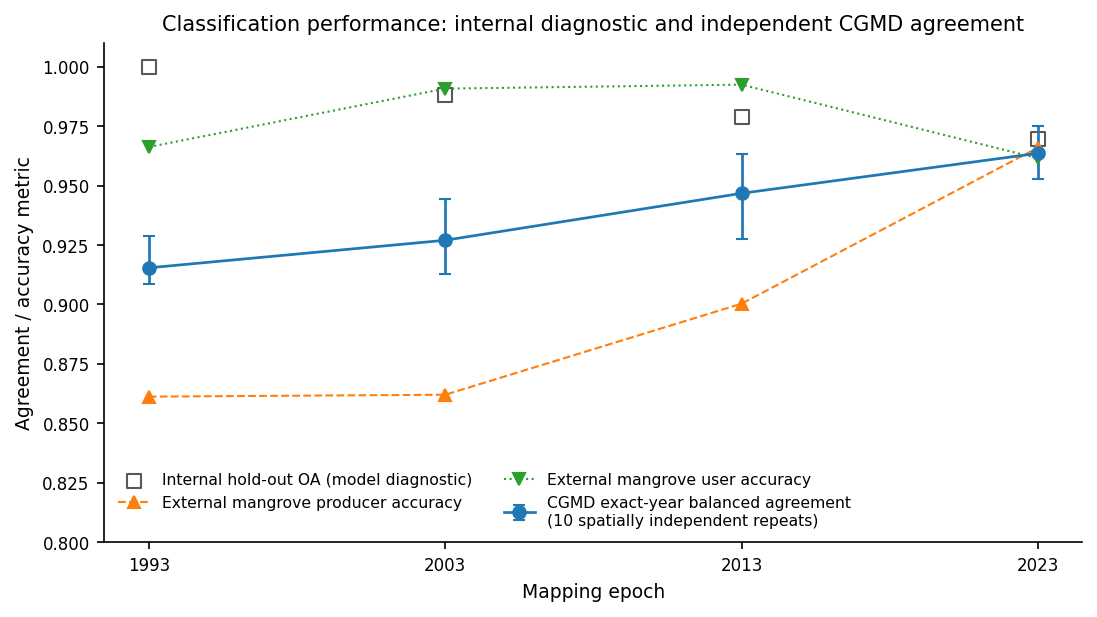

In [ ]:
# 8. Main publication figure — independent CGMD agreement, with internal hold-out shown only as context
fig, ax = plt.subplots(figsize=(7.2, 4.0))

x = np.arange(len(EPOCHS))
ext = external_repeat_summary.set_index('year').loc[EPOCHS]
internal = val.set_index('year').loc[EPOCHS]

ext_mean = ext['balanced_agreement_mean'].to_numpy()
ext_lo = ext['agreement_q025'].to_numpy()
ext_hi = ext['agreement_q975'].to_numpy()
ext_err = np.vstack([ext_mean-ext_lo, ext_hi-ext_mean])

ax.errorbar(
    x, ext_mean,
    yerr=ext_err,
    fmt='o-', capsize=3, linewidth=1.3,
    label='CGMD exact-year balanced agreement\n(10 spatially independent repeats)'
)

ax.scatter(
    x, internal['OA'].to_numpy(),
    marker='s', facecolors='none', edgecolors='0.35',
    s=45, label='Internal hold-out OA (model diagnostic)'
)

ax.plot(
    x, ext['PA_mangrove_mean'].to_numpy(),
    marker='^', linestyle='--', linewidth=1.0,
    label='External mangrove producer accuracy'
)

ax.plot(
    x, ext['UA_mangrove_mean'].to_numpy(),
    marker='v', linestyle=':', linewidth=1.0,
    label='External mangrove user accuracy'
)

ax.set_xticks(x, EPOCHS)
ax.set_ylim(0.80, 1.01)
ax.set_xlabel('Mapping epoch')
ax.set_ylabel('Agreement / accuracy metric')
ax.set_title('Classification performance: internal diagnostic and independent CGMD agreement')
ax.legend(frameon=False, ncol=2, fontsize=7.5)

save_figure('Fig01_external_CGMD_agreement')
plt.show()


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/FigS01_CGMD_external_confusion_matrices.png


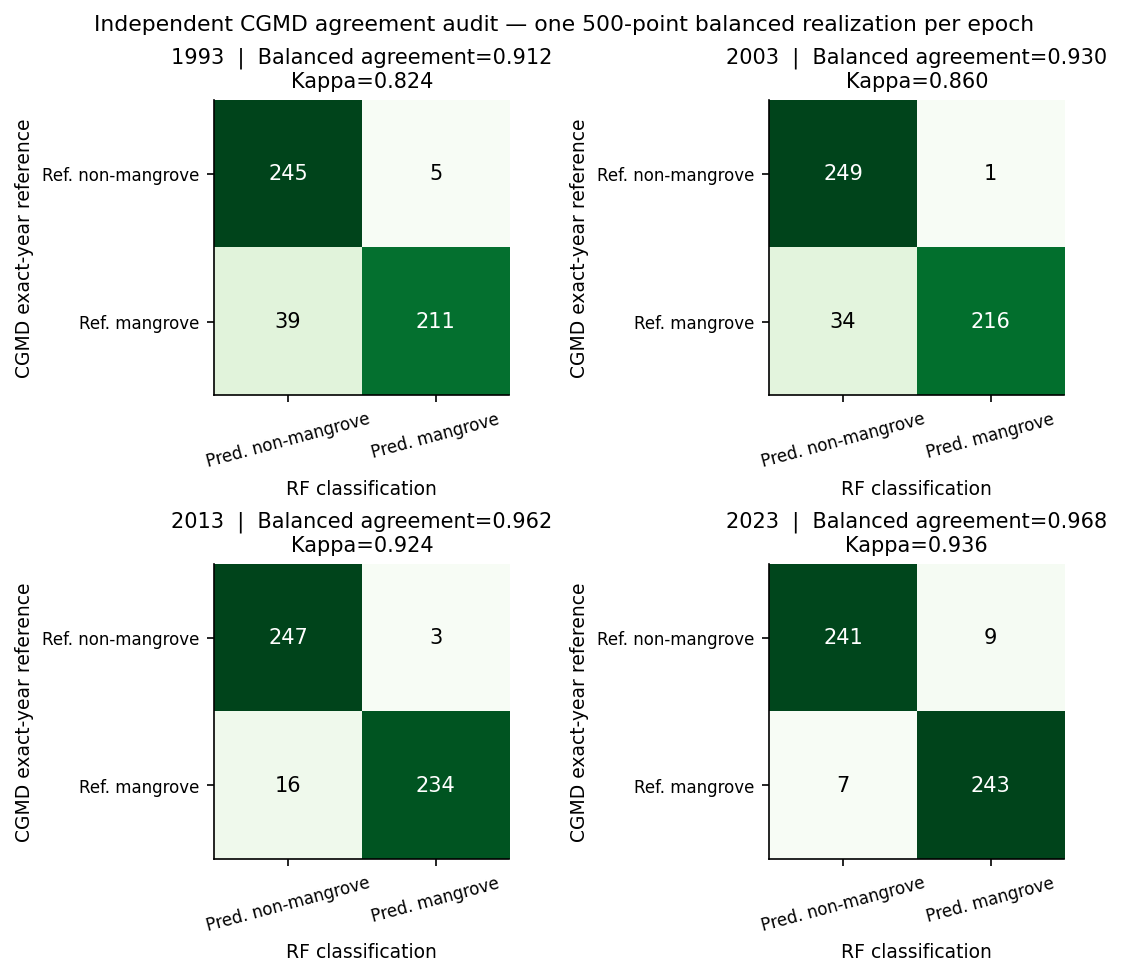

In [ ]:
# 9. Supplementary figure — exact-year CGMD point-level confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(7.4, 6.4))
axes = axes.ravel()

for ax, year in zip(axes, EPOCHS):
    row = external_cm.loc[external_cm['year'].eq(year)].iloc[0]
    cm = np.array([
        [row.TN, row.FP],
        [row.FN, row.TP]
    ], dtype=float)

    im = ax.imshow(cm, cmap='Greens')
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f'{int(cm[i,j])}',
                ha='center', va='center',
                fontsize=10,
                color='white' if cm[i,j] > cm.max()*0.55 else 'black'
            )

    metric = external_points.loc[external_points['year'].eq(year)].iloc[0]
    ax.set_title(
        f'{year}  |  Balanced agreement={metric.balanced_accuracy:.3f}\n'
        f'Kappa={metric.Kappa:.3f}'
    )
    ax.set_xticks([0,1], ['Pred. non-mangrove','Pred. mangrove'], rotation=15)
    ax.set_yticks([0,1], ['Ref. non-mangrove','Ref. mangrove'])
    ax.set_xlabel('RF classification')
    ax.set_ylabel('CGMD exact-year reference')

fig.suptitle(
    'Independent CGMD agreement audit — one 500-point balanced realization per epoch',
    fontsize=10.5
)
save_figure('FigS01_CGMD_external_confusion_matrices')
plt.show()


In [ ]:
# 10. Supplementary spatial-block separability sensitivity of the original hold-out samples
#    This is retained only as a supplementary diagnostic; the CGMD audit is the main external comparison.
PREDICTORS = ['blue','green','red','nir','swir1','swir2','NDVI','EVI','NDMI','MNDWI','NBR','BSI']
spatial_cv_rows = []

for year, v0 in validation_data.items():
    v = v0.copy()
    coords = v['.geo'].apply(parse_geo_point)
    v['lon'] = [x[0] for x in coords]
    v['lat'] = [x[1] for x in coords]
    use_cols = [c for c in PREDICTORS if c in v.columns]
    v = v.dropna(subset=['lon','lat','label',*use_cols]).copy()

    # ~3.3 km blocks at the equator; sensitivity only.
    cell = 0.03
    gx = np.floor((v['lon'] - v['lon'].min()) / cell).astype(int)
    gy = np.floor((v['lat'] - v['lat'].min()) / cell).astype(int)
    v['spatial_group'] = gx.astype(str) + '_' + gy.astype(str)
    n_groups = v['spatial_group'].nunique()
    n_splits = min(5, n_groups)

    if n_splits < 3 or len(v) < 30:
        spatial_cv_rows.append({'year':year,'status':'insufficient_groups','n':len(v),'groups':n_groups})
        continue

    X = v[use_cols].to_numpy()
    y = v['label'].astype(int).to_numpy()
    groups = v['spatial_group'].to_numpy()

    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    for fold, (tr, te) in enumerate(cv.split(X,y,groups), start=1):
        if len(np.unique(y[tr])) < 2 or len(np.unique(y[te])) < 2:
            continue
        model = RandomForestClassifier(
            n_estimators=300, random_state=42,
            class_weight='balanced', n_jobs=-1
        )
        model.fit(X[tr], y[tr])
        pred = model.predict(X[te])
        fold_scores.append({
            'balanced_accuracy': balanced_accuracy_score(y[te],pred),
            'F1': f1_score(y[te],pred,pos_label=1,zero_division=0),
            'Kappa': cohen_kappa_score(y[te],pred)
        })

    if fold_scores:
        f = pd.DataFrame(fold_scores)
        spatial_cv_rows.append({
            'year':year,'status':'ok','n':len(v),'groups':n_groups,'folds':len(f),
            'spatial_balanced_accuracy_mean':f['balanced_accuracy'].mean(),
            'spatial_balanced_accuracy_sd':f['balanced_accuracy'].std(ddof=1),
            'spatial_F1_mean':f['F1'].mean(),
            'spatial_Kappa_mean':f['Kappa'].mean()
        })

spatial_cv = pd.DataFrame(spatial_cv_rows)
spatial_cv.to_csv(TAB/'03_spatial_block_sensitivity.csv', index=False)
display(spatial_cv)


,year,status,n,groups,folds,spatial_balanced_accuracy_mean,spatial_balanced_accuracy_sd,spatial_F1_mean,spatial_Kappa_mean
0,1993,ok,102,62,5,0.977500,0.031125,0.979950,0.958037
1,2003,ok,83,54,5,0.913095,0.108261,0.877778,0.847056
2,2013,ok,95,59,5,0.957778,0.042601,0.943791,0.915737
3,2023,ok,66,47,5,0.923611,0.049105,0.899913,0.839905


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig02_RF_predictor_importance.png


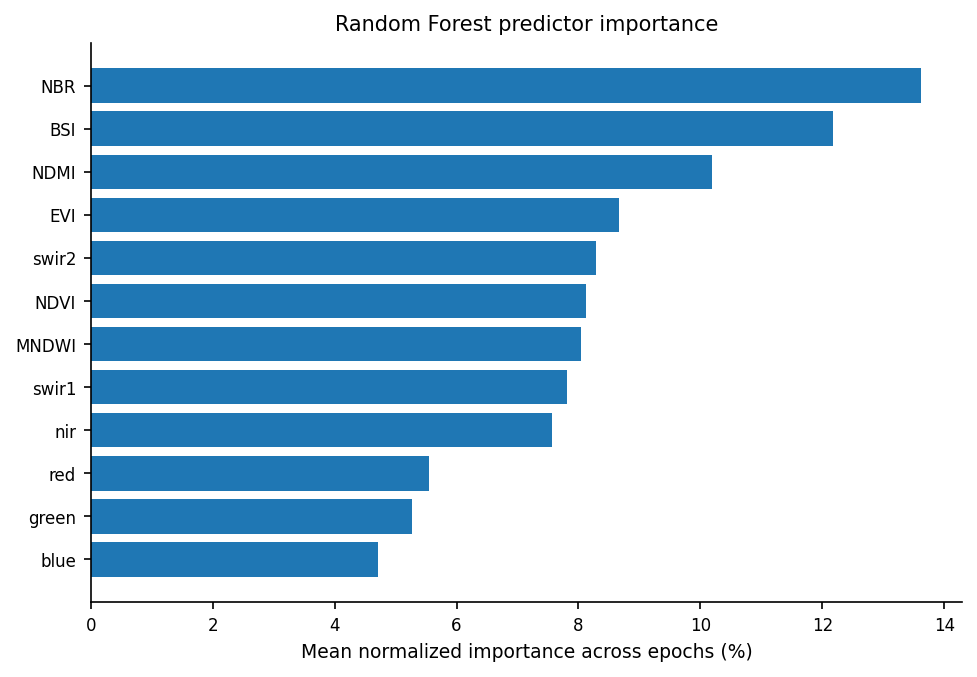

In [ ]:
# 9. RF importance — normalized within each epoch for cross-year comparability
imp_frames = []
for year in EPOCHS:
    x = read_csv(f'MMFR_RF_importance_{year}.csv')
    x['year'] = year
    x['importance'] = pd.to_numeric(x['importance'], errors='coerce')
    x['importance_pct'] = 100 * x['importance'] / x['importance'].sum()
    imp_frames.append(x[['year','feature','importance','importance_pct']])
imp = pd.concat(imp_frames, ignore_index=True)
mean_imp = (imp.groupby('feature',as_index=False)['importance_pct'].mean()
              .sort_values('importance_pct'))
imp.to_csv(TAB/'04_RF_importance_by_epoch.csv', index=False)
mean_imp.to_csv(TAB/'05_RF_importance_mean.csv', index=False)

fig, ax = plt.subplots(figsize=(6.4,4.4))
ax.barh(mean_imp['feature'], mean_imp['importance_pct'])
ax.set_xlabel('Mean normalized importance across epochs (%)')
ax.set_title('Random Forest predictor importance')
save_figure('Fig02_RF_predictor_importance')
plt.show()


# B. Extent, RF probability sensitivity, and independent CGMD context

The four RF snapshots are the study-specific mapped products. CGMD provides an independent annual context. Divergence between the two is treated as a result to diagnose, not as evidence that one product is automatically correct.


,year,raw_mapped_area_ha,probability_weighted_support_area_ha,CGMD_extent_area_ha,RF_minus_CGMD_ha,RF_minus_CGMD_pct
0,1993,36058.131986,43303.175276,42972.021887,-6913.889901,-16.089282
1,2003,35180.199872,43499.452647,42756.819037,-7576.619166,-17.720259
2,2013,36239.007698,43629.039571,41565.012185,-5326.004487,-12.813672
3,2023,38934.165095,55286.373960,41282.374556,-2348.209461,-5.688165


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig03_extent_RF_vs_CGMD.png


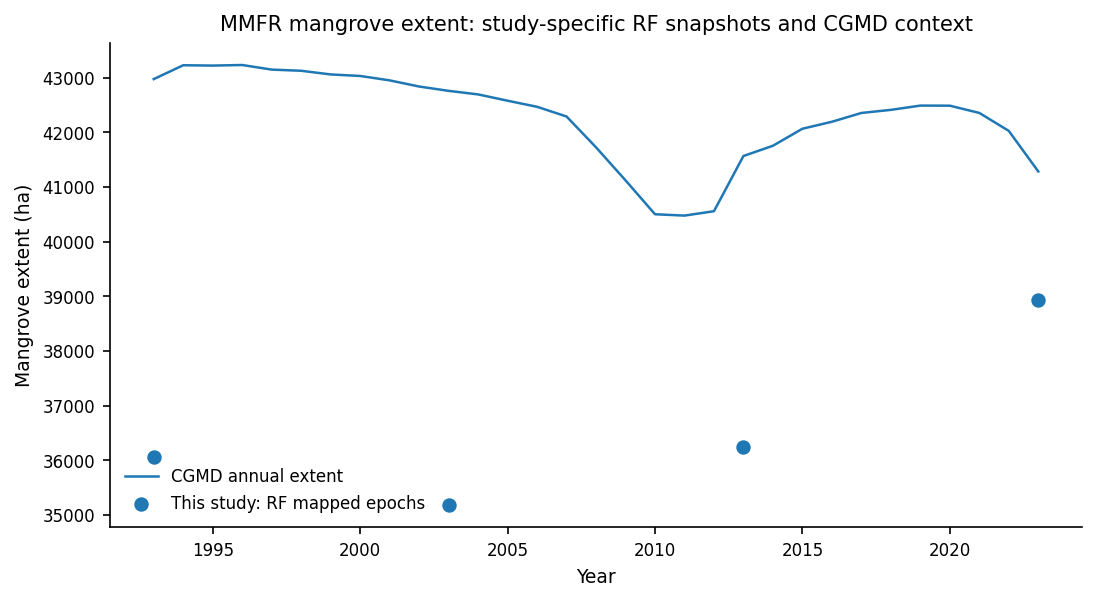

In [ ]:
# 10. RF epoch extent vs annual CGMD context
rf_cgmd = epoch[['year','raw_mapped_area_ha','probability_weighted_support_area_ha']].merge(
    cgmd[['year','CGMD_extent_area_ha']], on='year', how='left'
)
rf_cgmd['RF_minus_CGMD_ha'] = rf_cgmd['raw_mapped_area_ha'] - rf_cgmd['CGMD_extent_area_ha']
rf_cgmd['RF_minus_CGMD_pct'] = 100 * rf_cgmd['RF_minus_CGMD_ha'] / rf_cgmd['CGMD_extent_area_ha']
rf_cgmd.to_csv(TAB/'06_RF_CGMD_epoch_comparison.csv', index=False)
display(rf_cgmd)

fig, ax = plt.subplots(figsize=(7.2,3.9))
ax.plot(cgmd['year'], cgmd['CGMD_extent_area_ha'], linewidth=1.2, label='CGMD annual extent')
ax.scatter(epoch['year'], epoch['raw_mapped_area_ha'], s=35, zorder=3, label='This study: RF mapped epochs')
ax.set_xlabel('Year')
ax.set_ylabel('Mangrove extent (ha)')
ax.set_title('MMFR mangrove extent: study-specific RF snapshots and CGMD context')
ax.legend(frameon=False)
save_figure('Fig03_extent_RF_vs_CGMD')
plt.show()


,year,prob_min,prob_p25,prob_median,prob_p75,prob_p99,hard_vs_p05_mismatch_pct
0,1993,0.019179,0.030279,0.049289,0.167004,0.982793,0.501873
1,2003,0.017753,0.029592,0.053794,0.220641,0.976597,0.446709
2,2013,0.018809,0.030841,0.037819,0.199088,0.978115,0.108277
3,2023,0.022574,0.131819,0.171304,0.365771,0.970077,0.087901


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig04_probability_threshold_sensitivity.png


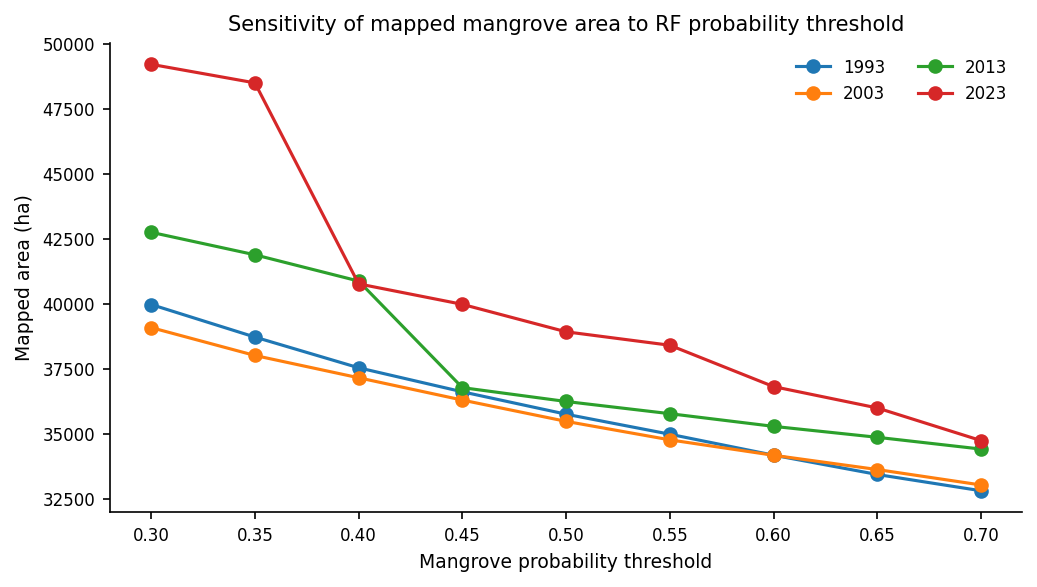

In [ ]:
# 11. RF probability threshold sensitivity and hard-class agreement
thresholds = np.round(np.arange(0.30, 0.71, 0.05), 2)
threshold_rows = []
probability_summary = []

for year in EPOCHS:
    p = ROOT / f'MMFR_RF_class_probability_{year}.tif'
    with rasterio.open(p) as src:
        hard = src.read(1).astype(float)
        prob = src.read(2).astype(float)
        row_area = geodesic_row_pixel_area_ha(src)

    mismatch = np.mean((hard >= 0.5) != (prob >= 0.5)) * 100
    probability_summary.append({
        'year':year,
        'prob_min':np.nanmin(prob),
        'prob_p25':np.nanpercentile(prob,25),
        'prob_median':np.nanmedian(prob),
        'prob_p75':np.nanpercentile(prob,75),
        'prob_p99':np.nanpercentile(prob,99),
        'hard_vs_p05_mismatch_pct':mismatch
    })
    for th in thresholds:
        area = raster_mask_area_ha(prob >= th, row_area)
        threshold_rows.append({'year':year,'threshold':th,'area_ha':area})

threshold_df = pd.DataFrame(threshold_rows)
prob_summary = pd.DataFrame(probability_summary)
threshold_df.to_csv(TAB/'07_probability_threshold_sensitivity.csv', index=False)
prob_summary.to_csv(TAB/'08_probability_distribution_summary.csv', index=False)
display(prob_summary)

fig, ax = plt.subplots(figsize=(6.8,3.8))
for year, d in threshold_df.groupby('year'):
    ax.plot(d['threshold'], d['area_ha'], marker='o', label=str(year))
ax.set_xlabel('Mangrove probability threshold')
ax.set_ylabel('Mapped area (ha)')
ax.set_title('Sensitivity of mapped mangrove area to RF probability threshold')
ax.legend(frameon=False, ncol=2)
save_figure('Fig04_probability_threshold_sensitivity')
plt.show()


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig05_probability_distributions.png


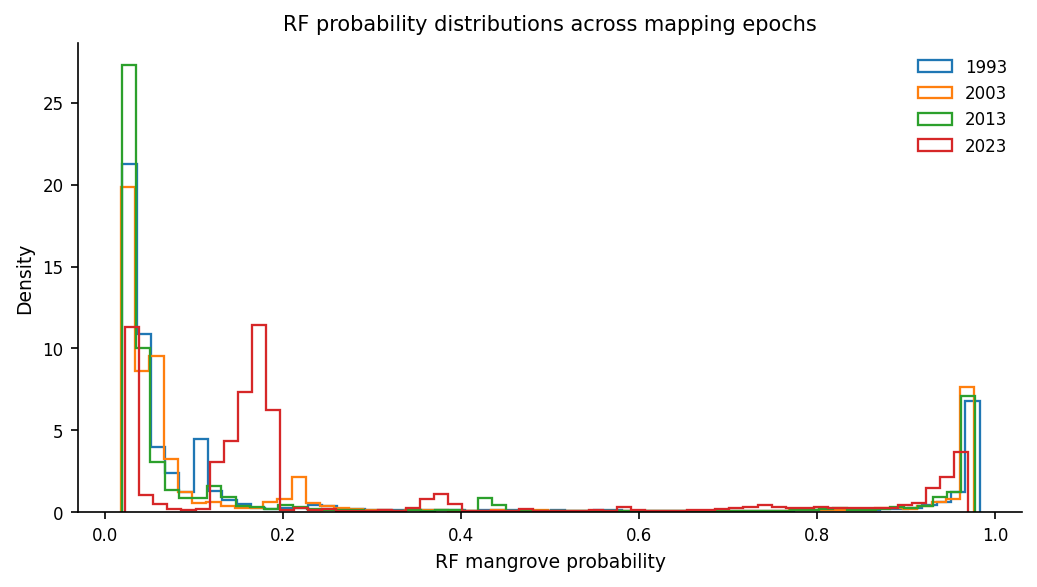

In [ ]:
# 12. Probability distribution comparison — sampled for efficient plotting
rng = np.random.default_rng(42)
fig, ax = plt.subplots(figsize=(6.8,3.8))
for year in EPOCHS:
    with rasterio.open(ROOT/f'MMFR_RF_class_probability_{year}.tif') as src:
        prob = src.read(2).astype(float).ravel()
    prob = prob[np.isfinite(prob)]
    if len(prob) > 150000:
        prob = rng.choice(prob, 150000, replace=False)
    ax.hist(prob, bins=60, density=True, histtype='step', linewidth=1.1, label=str(year))
ax.set_xlabel('RF mangrove probability')
ax.set_ylabel('Density')
ax.set_title('RF probability distributions across mapping epochs')
ax.legend(frameon=False)
save_figure('Fig05_probability_distributions')
plt.show()


,code,class,area_ha,share_pct
0,0,Persistent non-mangrove,142418.325667,76.272875
1,1,Loss,5369.445757,2.875635
2,2,Gain,8244.911334,4.415605
3,3,Persistent mangrove,30689.432605,16.435885


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig06_change_composition.png


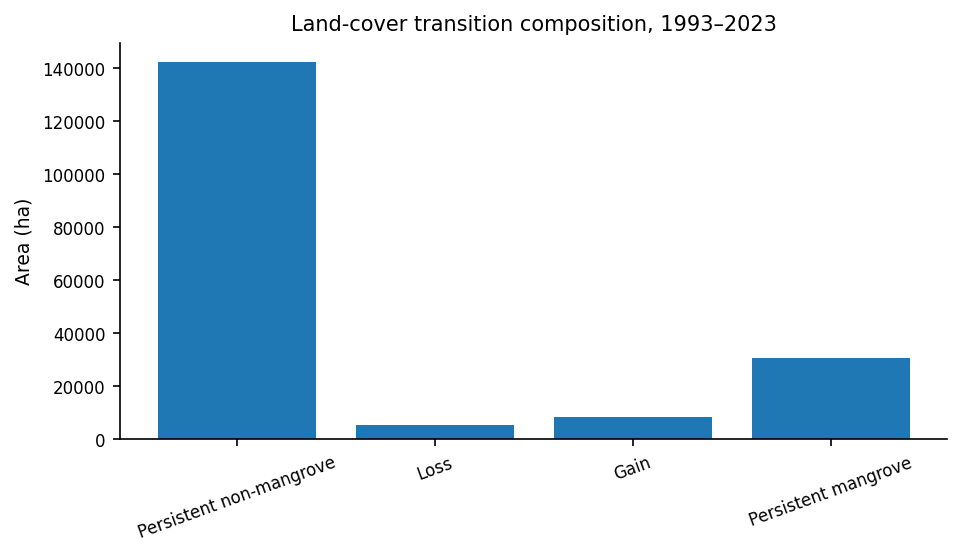

In [ ]:
# 13. 1993–2023 change composition from the change raster
change_names = {
    0:'Persistent non-mangrove',
    1:'Loss',
    2:'Gain',
    3:'Persistent mangrove'
}
with rasterio.open(ROOT/'MMFR_change_1993_2023.tif') as src:
    change = src.read(1)
    row_area = geodesic_row_pixel_area_ha(src)

change_rows = []
for code_id, label in change_names.items():
    area = raster_mask_area_ha(change == code_id, row_area)
    change_rows.append({'code':code_id,'class':label,'area_ha':area})
change_area = pd.DataFrame(change_rows)
change_area['share_pct'] = 100 * change_area['area_ha'] / change_area['area_ha'].sum()
change_area.to_csv(TAB/'09_change_composition_1993_2023.csv', index=False)
display(change_area)

fig, ax = plt.subplots(figsize=(6.3,3.6))
ax.bar(change_area['class'], change_area['area_ha'])
ax.set_ylabel('Area (ha)')
ax.set_title('Land-cover transition composition, 1993–2023')
ax.tick_params(axis='x', rotation=20)
save_figure('Fig06_change_composition')
plt.show()


# C. Annual mangrove condition and independent sensor/product sensitivity


In [ ]:
# 14. Robust trend table for annual condition, CGMD extent/FCC, and climate variables
trend_vars = [
    'NDVI_median','EVI_median','NDMI_median','MNDWI_median','NBR_median',
    'CGMD_extent_area_ha','CGMD_FCC_pct_mean','CGMD_FCC_pct_median',
    'precipitation_mm','sea_surface_elevation_anomaly_m',
    'sea_surface_temperature_C','sea_surface_salinity_psu',
    'air_temperature_2m_C','VPD_kPa'
]
trend_vars = [c for c in trend_vars if c in annual.columns]
trend_table = pd.DataFrame([trend_summary(annual,c) for c in trend_vars])
trend_table.to_csv(TAB/'10_robust_trend_tests.csv', index=False)
display(trend_table)


,variable,n,MK_tau,MK_p,HamedRao_p,HamedRao_trend,TheilSen_slope_per_year,TheilSen_95_lo,TheilSen_95_hi,Pettitt_year,Pettitt_p
0,NDVI_median,31,0.509677,0.000060,0.000060,increasing,0.001482,0.000831,0.002085,2011,0.000367
1,EVI_median,31,0.427957,0.000765,0.026818,increasing,0.001243,0.000533,0.001837,2011,0.001746
2,NDMI_median,31,-0.277419,0.029590,0.090993,no trend,-0.000604,-0.001204,-0.000001,2000,0.010520
3,MNDWI_median,31,-0.402151,0.001570,0.008234,decreasing,-0.002600,-0.003892,-0.001155,2010,0.010520
4,NBR_median,31,-0.384946,0.002483,0.002483,decreasing,-0.000780,-0.001170,-0.000196,2000,0.054172
5,CGMD_extent_area_ha,31,-0.548387,0.000016,0.006759,decreasing,-49.243800,-72.102325,-32.252287,2005,0.000046
6,CGMD_FCC_pct_mean,31,-0.122581,0.341199,0.426463,no trend,-0.022079,-0.079048,0.032825,2011,0.090319
7,CGMD_FCC_pct_median,31,-0.187097,0.121617,0.121617,no trend,0.000000,-0.071429,0.000000,2001,0.090319
8,precipitation_mm,31,0.088172,0.496595,0.496595,no trend,5.739319,-6.350089,19.748720,2007,0.610243
9,sea_surface_elevation_anomaly_m,31,-0.264516,0.038120,0.115981,no trend,-0.002564,-0.004412,-0.000105,2016,0.031248


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig07_annual_NDMI_trend.png


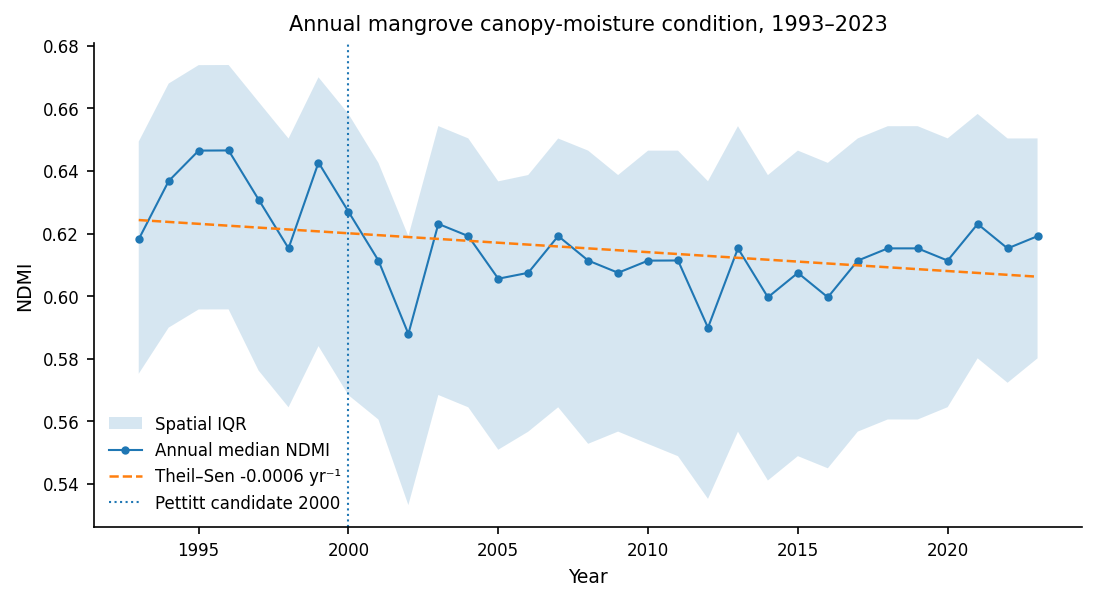

In [ ]:
# 15. Main annual canopy-condition figure: NDMI + spatial IQR + Theil–Sen trend
response = 'NDMI_median'
d = land[['year','NDMI_median','NDMI_p25','NDMI_p75']].dropna().copy()
slope, intercept, lo, hi = theilslopes(d['NDMI_median'], d['year'], 0.95)
fit = intercept + slope * d['year']
pet = pettitt_test(d['NDMI_median'], d['year'])

fig, ax = plt.subplots(figsize=(7.2,3.9))
ax.fill_between(d['year'], d['NDMI_p25'], d['NDMI_p75'], alpha=0.18, label='Spatial IQR')
ax.plot(d['year'], d['NDMI_median'], marker='o', markersize=3, linewidth=1, label='Annual median NDMI')
ax.plot(d['year'], fit, linestyle='--', linewidth=1.2, label=f'Theil–Sen {slope:+.4f} yr⁻¹')
if np.isfinite(pet['year']):
    ax.axvline(pet['year'], linestyle=':', linewidth=1, label=f'Pettitt candidate {pet["year"]}')
ax.set_xlabel('Year')
ax.set_ylabel('NDMI')
ax.set_title('Annual mangrove canopy-moisture condition, 1993–2023')
ax.legend(frameon=False)
save_figure('Fig07_annual_NDMI_trend')
plt.show()


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/FigS01_annual_EVI.png


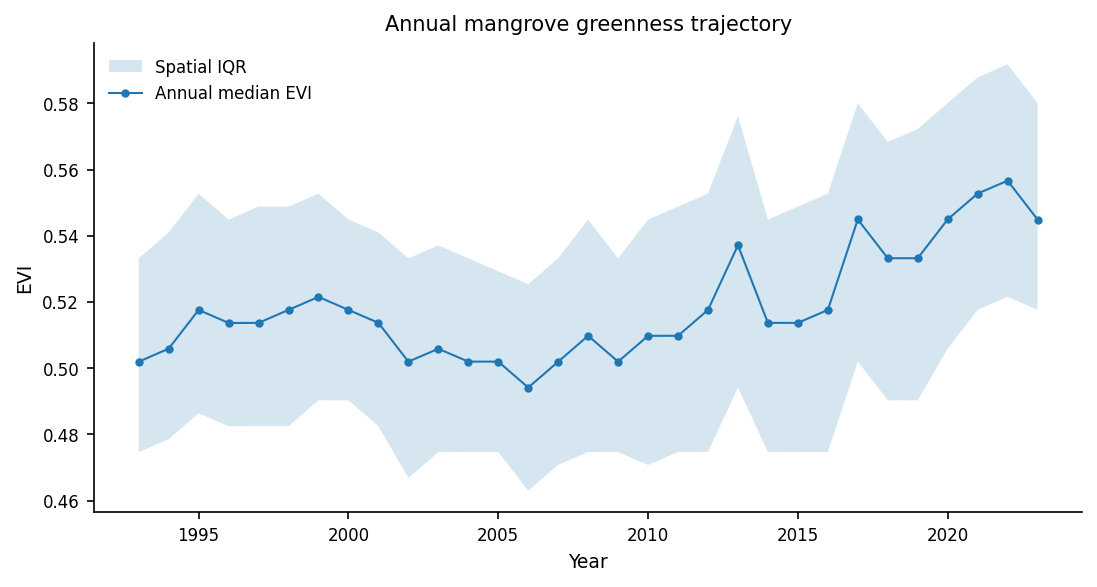

In [ ]:
# 16. Supplementary annual EVI trajectory
fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.fill_between(land['year'], land['EVI_p25'], land['EVI_p75'], alpha=0.18, label='Spatial IQR')
ax.plot(land['year'], land['EVI_median'], marker='o', markersize=3, linewidth=1, label='Annual median EVI')
ax.set_xlabel('Year')
ax.set_ylabel('EVI')
ax.set_title('Annual mangrove greenness trajectory')
ax.legend(frameon=False)
save_figure('FigS01_annual_EVI')
plt.show()


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig08_CGMD_annual_extent.png


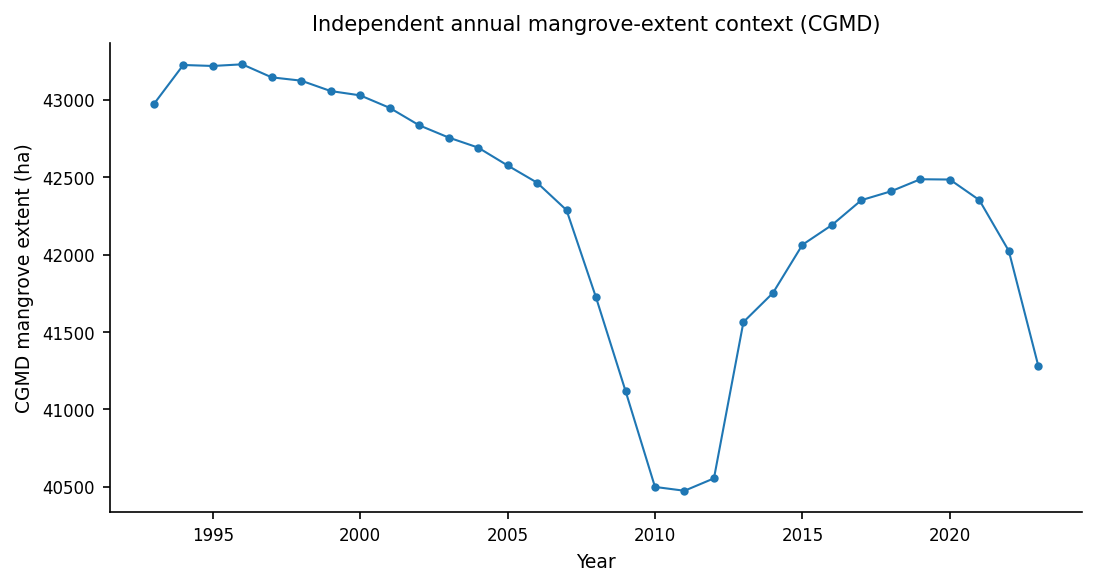

{'variable': 'CGMD_extent_area_ha', 'n': 31, 'MK_tau': np.float64(-0.5483870967741935), 'MK_p': np.float64(1.5809977126357566e-05), 'HamedRao_p': np.float64(0.006758899282802711), 'HamedRao_trend': 'decreasing', 'TheilSen_slope_per_year': np.float64(-49.24380028741507), 'TheilSen_95_lo': np.float64(-72.10232528397486), 'TheilSen_95_hi': np.float64(-32.25228712400227), 'Pettitt_year': 2005, 'Pettitt_p': np.float64(4.584449073397921e-05)}


In [ ]:
# 17. CGMD annual extent trajectory
cgmd_extent_trend = trend_summary(cgmd, 'CGMD_extent_area_ha')
fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.plot(cgmd['year'], cgmd['CGMD_extent_area_ha'], marker='o', markersize=3, linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('CGMD mangrove extent (ha)')
ax.set_title('Independent annual mangrove-extent context (CGMD)')
save_figure('Fig08_CGMD_annual_extent')
plt.show()
print(cgmd_extent_trend)


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig09_CGMD_fractional_canopy_cover.png


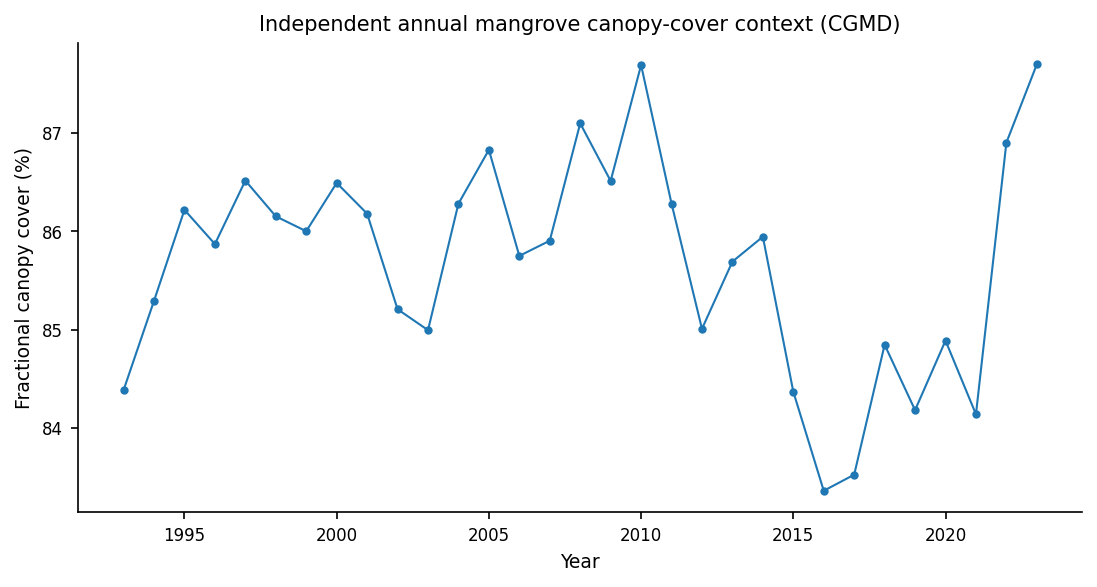

In [ ]:
# 18. CGMD fractional canopy cover trajectory
fcc_col = 'CGMD_FCC_pct_mean'
fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.plot(cgmd['year'], cgmd[fcc_col], marker='o', markersize=3, linewidth=1)
ax.set_xlabel('Year')
ax.set_ylabel('Fractional canopy cover (%)')
ax.set_title('Independent annual mangrove canopy-cover context (CGMD)')
save_figure('Fig09_CGMD_fractional_canopy_cover')
plt.show()


,n,rho_raw,p_raw,rho_detrended,p_detrended
0,23,0.062253,0.777806,0.341897,0.110312


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig10_Landsat_MODIS_EVI_sensitivity.png


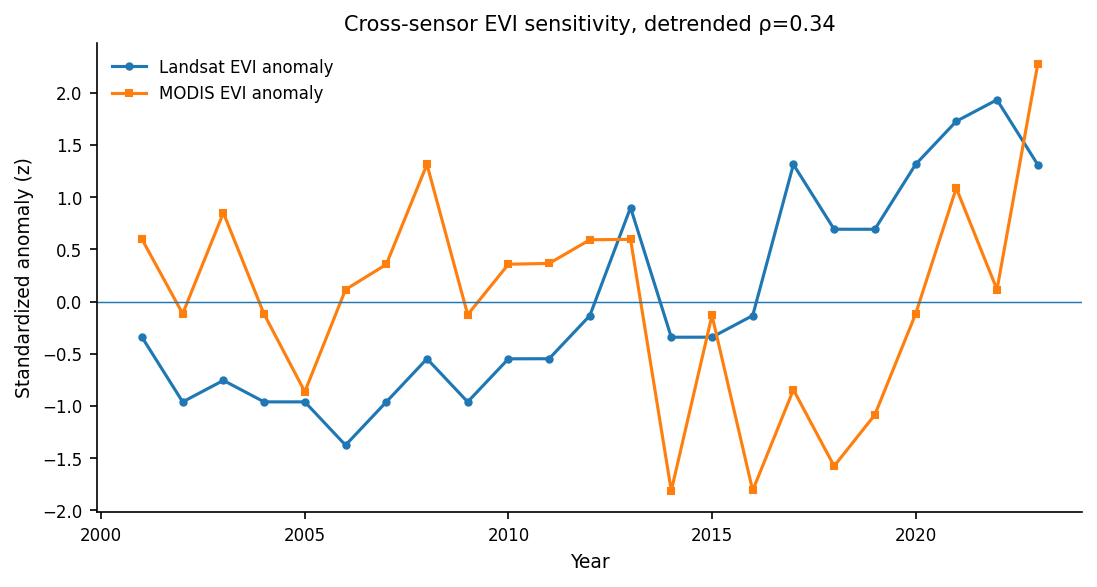

In [ ]:
# 19. Landsat–MODIS cross-sensor EVI sensitivity
modis_evi_col = 'MODIS_EVI_median'
rob = land[['year','EVI_median']].merge(modis[['year',modis_evi_col]], on='year', how='inner').dropna()
rob['Landsat_EVI_z'] = (rob['EVI_median']-rob['EVI_median'].mean())/rob['EVI_median'].std(ddof=1)
rob['MODIS_EVI_z'] = (rob[modis_evi_col]-rob[modis_evi_col].mean())/rob[modis_evi_col].std(ddof=1)
rob['Landsat_dt'] = detrend_series(rob['EVI_median'])
rob['MODIS_dt'] = detrend_series(rob[modis_evi_col])
rho_raw, p_raw = spearmanr(rob['EVI_median'], rob[modis_evi_col])
rho_dt, p_dt = spearmanr(rob['Landsat_dt'], rob['MODIS_dt'])

cross_sensor = pd.DataFrame([{
    'n':len(rob),'rho_raw':rho_raw,'p_raw':p_raw,
    'rho_detrended':rho_dt,'p_detrended':p_dt
}])
cross_sensor.to_csv(TAB/'11_Landsat_MODIS_cross_sensor.csv', index=False)
display(cross_sensor)

fig, ax = plt.subplots(figsize=(7.2,3.8))
ax.plot(rob['year'], rob['Landsat_EVI_z'], marker='o', markersize=3, label='Landsat EVI anomaly')
ax.plot(rob['year'], rob['MODIS_EVI_z'], marker='s', markersize=3, label='MODIS EVI anomaly')
ax.axhline(0, linewidth=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Standardized anomaly (z)')
ax.set_title(f'Cross-sensor EVI sensitivity, detrended ρ={rho_dt:.2f}')
ax.legend(frameon=False)
save_figure('Fig10_Landsat_MODIS_EVI_sensitivity')
plt.show()


# D. Climate/ocean quality control and association analysis

The annual HYCOM series contains visually unusual years (notably sea-surface elevation in 2001 and salinity in 2018/2020 in the current export). The notebook does **not** silently delete them. It flags robust anomalies and reports models both with all years and with a sensitivity subset excluding automatically flagged primary-driver years.


In [ ]:
# 20. Robust climate/ocean anomaly screening
DRIVERS = [
    'precipitation_mm',
    'sea_surface_elevation_anomaly_m',
    'sea_surface_temperature_C',
    'sea_surface_salinity_psu',
    'air_temperature_2m_C',
    'VPD_kPa'
]
DRIVERS = [c for c in DRIVERS if c in clim.columns]

climate_qc = clim[['year']+DRIVERS].copy()
flag_rows = []
for c in DRIVERS:
    climate_qc[c+'_robust_z'] = robust_modified_zscore(climate_qc[c])
    climate_qc[c+'_flag'] = climate_qc[c+'_robust_z'].abs() > 3.5
    flagged = climate_qc.loc[climate_qc[c+'_flag'], ['year',c,c+'_robust_z']]
    for _, r in flagged.iterrows():
        flag_rows.append({'driver':c,'year':int(r['year']),'value':r[c],'robust_z':r[c+'_robust_z']})

climate_flags = pd.DataFrame(flag_rows)
climate_qc.to_csv(TAB/'12_climate_robust_QC.csv', index=False)
climate_flags.to_csv(TAB/'13_climate_flagged_years.csv', index=False)
print('Robust anomaly flags:')
display(climate_flags)


Robust anomaly flags:


,driver,year,value,robust_z
0,sea_surface_elevation_anomaly_m,2001,0.235469,-5.621072
1,sea_surface_salinity_psu,2018,24.504665,-5.317943
2,sea_surface_salinity_psu,2020,24.623666,-5.206112


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig11_climate_ocean_anomaly_heatmap.png


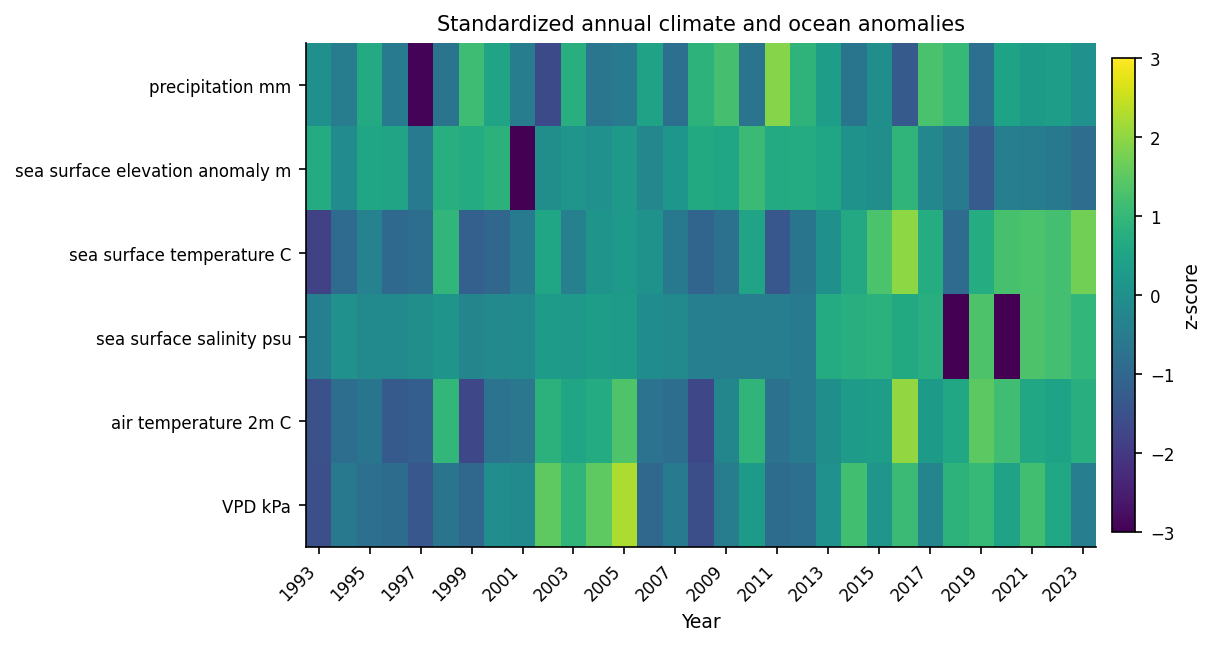

In [ ]:
# 21. Standardized climate/ocean anomaly heatmap
z = clim[['year']+DRIVERS].copy()
for c in DRIVERS:
    z[c] = (z[c]-z[c].mean())/z[c].std(ddof=1)

matrix = z[DRIVERS].to_numpy().T
fig, ax = plt.subplots(figsize=(8.0,4.2))
im = ax.imshow(matrix, aspect='auto', vmin=-3, vmax=3)
ax.set_yticks(np.arange(len(DRIVERS)), [c.replace('_',' ') for c in DRIVERS])
# show every second year for readability
idx = np.arange(0,len(z),2)
ax.set_xticks(idx, z['year'].astype(int).iloc[idx], rotation=45, ha='right')
ax.set_xlabel('Year')
ax.set_title('Standardized annual climate and ocean anomalies')
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label('z-score')
save_figure('Fig11_climate_ocean_anomaly_heatmap')
plt.show()


In [ ]:
# 22. Detrended lagged Spearman associations with FDR correction
# Positive lag = driver at t-lag compared with response at t.
responses = ['NDMI_median','CGMD_FCC_pct_mean']
lag_rows = []

work = annual[['year'] + responses + DRIVERS].copy()
for c in responses + DRIVERS:
    work[c+'_dt'] = detrend_series(work[c])

for response_name in responses:
    for drv in DRIVERS:
        for lag_n in [0,1,2,3]:
            tmp = pd.DataFrame({
                'y':work[response_name+'_dt'],
                'x':work[drv+'_dt'].shift(lag_n)
            }).dropna()
            if len(tmp) >= 10:
                rho, p = spearmanr(tmp['x'],tmp['y'])
            else:
                rho, p = np.nan, np.nan
            lag_rows.append({
                'response':response_name,'driver':drv,'lag_years':lag_n,
                'n':len(tmp),'spearman_rho':rho,'p_raw':p
            })

lag = pd.DataFrame(lag_rows)
for response_name in responses:
    m = lag['response'].eq(response_name) & lag['p_raw'].notna()
    lag.loc[m,'p_FDR'] = multipletests(lag.loc[m,'p_raw'], method='fdr_bh')[1]
lag.to_csv(TAB/'14_lagged_detrended_associations.csv', index=False)
display(lag.sort_values(['response','p_FDR']).head(20))


,response,driver,lag_years,n,spearman_rho,p_raw,p_FDR
31,CGMD_FCC_pct_mean,sea_surface_elevation_anomaly_m,3,28,-0.446634,0.017191,0.412577
38,CGMD_FCC_pct_mean,sea_surface_salinity_psu,2,29,-0.385222,0.039052,0.468621
41,CGMD_FCC_pct_mean,air_temperature_2m_C,1,30,-0.333482,0.071720,0.573761
26,CGMD_FCC_pct_mean,precipitation_mm,2,29,0.273399,0.151275,0.633080
27,CGMD_FCC_pct_mean,precipitation_mm,3,28,-0.269841,0.164929,0.633080
33,CGMD_FCC_pct_mean,sea_surface_temperature_C,1,30,-0.248943,0.184648,0.633080
46,CGMD_FCC_pct_mean,VPD_kPa,2,29,-0.257635,0.177244,0.633080
35,CGMD_FCC_pct_mean,sea_surface_temperature_C,3,28,0.210181,0.283041,0.710660
36,CGMD_FCC_pct_mean,sea_surface_salinity_psu,0,31,-0.183065,0.324262,0.710660
42,CGMD_FCC_pct_mean,air_temperature_2m_C,2,29,-0.189163,0.325719,0.710660


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig12_lagged_association_NDMI.png


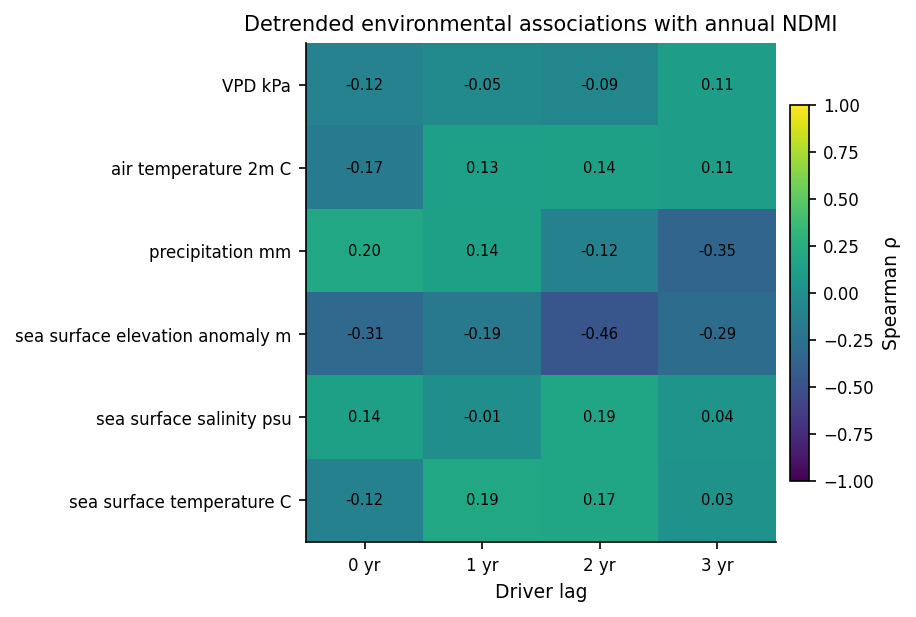

In [ ]:
# 23. Primary lag-correlation heatmap: Landsat NDMI
resp = 'NDMI_median'
d = lag[lag['response'].eq(resp)].copy()
rho = d.pivot(index='driver',columns='lag_years',values='spearman_rho')
pf = d.pivot(index='driver',columns='lag_years',values='p_FDR')

fig, ax = plt.subplots(figsize=(6.0,4.0))
im = ax.imshow(rho.values, aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(rho.columns)), [f'{x} yr' for x in rho.columns])
ax.set_yticks(np.arange(len(rho.index)), [x.replace('_',' ') for x in rho.index])
ax.set_xlabel('Driver lag')
ax.set_title('Detrended environmental associations with annual NDMI')
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        r = rho.iloc[i,j]
        p = pf.iloc[i,j]
        if pd.notna(r):
            star = '*' if pd.notna(p) and p < 0.05 else ''
            ax.text(j,i,f'{r:.2f}{star}',ha='center',va='center',fontsize=7)
cb = fig.colorbar(im,ax=ax,fraction=0.04,pad=0.03)
cb.set_label('Spearman ρ')
save_figure('Fig12_lagged_association_NDMI')
plt.show()


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/FigS02_lagged_association_CGMD_FCC.png


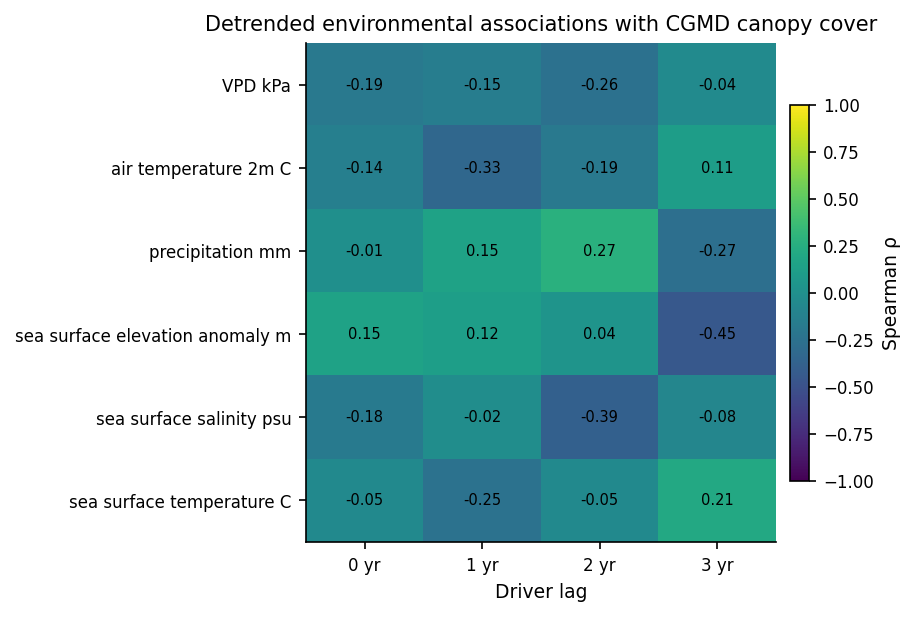

In [ ]:
# 24. Sensitivity lag-correlation heatmap: CGMD fractional canopy cover
resp = 'CGMD_FCC_pct_mean'
d = lag[lag['response'].eq(resp)].copy()
rho = d.pivot(index='driver',columns='lag_years',values='spearman_rho')
pf = d.pivot(index='driver',columns='lag_years',values='p_FDR')

fig, ax = plt.subplots(figsize=(6.0,4.0))
im = ax.imshow(rho.values, aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(rho.columns)), [f'{x} yr' for x in rho.columns])
ax.set_yticks(np.arange(len(rho.index)), [x.replace('_',' ') for x in rho.index])
ax.set_xlabel('Driver lag')
ax.set_title('Detrended environmental associations with CGMD canopy cover')
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        r = rho.iloc[i,j]
        p = pf.iloc[i,j]
        if pd.notna(r):
            star = '*' if pd.notna(p) and p < 0.05 else ''
            ax.text(j,i,f'{r:.2f}{star}',ha='center',va='center',fontsize=7)
cb = fig.colorbar(im,ax=ax,fraction=0.04,pad=0.03)
cb.set_label('Spearman ρ')
save_figure('FigS02_lagged_association_CGMD_FCC')
plt.show()


In [ ]:
# 25. Small HAC/Newey-West multivariable association model + robust-year sensitivity
PRIMARY_DRIVERS = [
    'precipitation_mm',
    'sea_surface_elevation_anomaly_m',
    'sea_surface_temperature_C',
    'sea_surface_salinity_psu'
]
PRIMARY_DRIVERS = [c for c in PRIMARY_DRIVERS if c in annual.columns]

model_base = annual[['year','NDMI_median']+PRIMARY_DRIVERS].copy()
model_base['NDMI_dt'] = detrend_series(model_base['NDMI_median'])
for c in PRIMARY_DRIVERS:
    model_base[c+'_dt'] = detrend_series(model_base[c])

flagged_primary_years = set()
if not climate_flags.empty:
    flagged_primary_years = set(
        climate_flags.loc[climate_flags['driver'].isin(PRIMARY_DRIVERS),'year'].astype(int)
    )

model_outputs = []
vif_outputs = []
model_fits = {}

for model_name, data in {
    'All years': model_base,
    'Exclude robust driver outliers': model_base[~model_base['year'].astype(int).isin(flagged_primary_years)]
}.items():
    cols = ['NDMI_dt']+[c+'_dt' for c in PRIMARY_DRIVERS]
    m = data[['year']+cols].dropna().copy()
    Xraw = m[[c+'_dt' for c in PRIMARY_DRIVERS]]
    X = pd.DataFrame(StandardScaler().fit_transform(Xraw),columns=PRIMARY_DRIVERS,index=m.index)
    y = (m['NDMI_dt']-m['NDMI_dt'].mean())/m['NDMI_dt'].std(ddof=1)
    Xc = sm.add_constant(X)
    fit = sm.OLS(y,Xc).fit(cov_type='HAC',cov_kwds={'maxlags':1})
    model_fits[model_name] = fit

    for i,c in enumerate(Xc.columns):
        vif_outputs.append({
            'model':model_name,'variable':c,
            'VIF':variance_inflation_factor(Xc.values,i)
        })

    ci = fit.conf_int()
    for var in PRIMARY_DRIVERS:
        model_outputs.append({
            'model':model_name,'variable':var,'n':len(m),
            'beta':fit.params[var],
            'ci_lo':ci.loc[var,0],
            'ci_hi':ci.loc[var,1],
            'p_HAC':fit.pvalues[var],
            'R2':fit.rsquared,
            'Adj_R2':fit.rsquared_adj,
            'Durbin_Watson':durbin_watson(fit.resid)
        })

coef = pd.DataFrame(model_outputs)
vif = pd.DataFrame(vif_outputs)
coef.to_csv(TAB/'15_HAC_driver_models.csv',index=False)
vif.to_csv(TAB/'16_HAC_model_VIF.csv',index=False)
display(coef)
display(vif)


,model,variable,n,beta,ci_lo,ci_hi,p_HAC,R2,Adj_R2,Durbin_Watson
0,All years,precipitation_mm,31,0.223587,-0.235081,0.682254,0.339363,0.046551,-0.100133,1.180047
1,All years,sea_surface_elevation_anomaly_m,31,-0.072174,-0.425874,0.281527,0.689204,0.046551,-0.100133,1.180047
2,All years,sea_surface_temperature_C,31,-0.002430,-0.427379,0.422519,0.991059,0.046551,-0.100133,1.180047
3,All years,sea_surface_salinity_psu,31,0.084435,-0.102935,0.271805,0.377117,0.046551,-0.100133,1.180047
4,Exclude robust driver outliers,precipitation_mm,28,0.331445,-0.133204,0.796094,0.162087,0.179570,0.036887,1.558052
5,Exclude robust driver outliers,sea_surface_elevation_anomaly_m,28,-0.294230,-0.666924,0.078464,0.121784,0.179570,0.036887,1.558052
6,Exclude robust driver outliers,sea_surface_temperature_C,28,-0.023352,-0.490610,0.443907,0.921971,0.179570,0.036887,1.558052
7,Exclude robust driver outliers,sea_surface_salinity_psu,28,0.172358,-0.311010,0.655726,0.484628,0.179570,0.036887,1.558052


,model,variable,VIF
0,All years,const,1.000000
1,All years,precipitation_mm,1.543941
2,All years,sea_surface_elevation_anomaly_m,1.058823
3,All years,sea_surface_temperature_C,1.649528
4,All years,sea_surface_salinity_psu,1.233505
5,Exclude robust driver outliers,const,1.000000
6,Exclude robust driver outliers,precipitation_mm,1.664142
7,Exclude robust driver outliers,sea_surface_elevation_anomaly_m,1.884561
8,Exclude robust driver outliers,sea_surface_temperature_C,1.985328
9,Exclude robust driver outliers,sea_surface_salinity_psu,2.281014


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig13_HAC_driver_coefficients.png


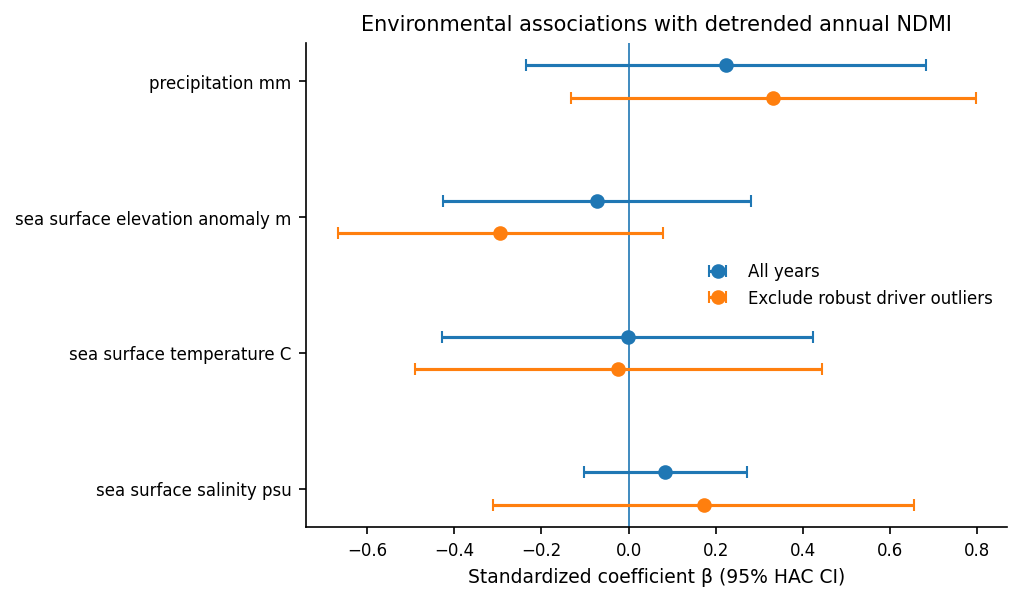

In [ ]:
# 26. Publication coefficient plot — all-years vs robust-outlier sensitivity
variables = PRIMARY_DRIVERS
y_base = np.arange(len(variables),dtype=float)
fig, ax = plt.subplots(figsize=(6.7,3.9))
ax.axvline(0,linewidth=0.8)

models = list(coef['model'].unique())
offsets = np.linspace(-0.12,0.12,len(models))
for offset, model_name in zip(offsets, models):
    d = coef[coef['model'].eq(model_name)].set_index('variable').loc[variables].reset_index()
    y = y_base + offset
    err = np.vstack([d['beta']-d['ci_lo'],d['ci_hi']-d['beta']])
    ax.errorbar(d['beta'],y,xerr=err,fmt='o',capsize=3,label=model_name)

ax.set_yticks(y_base,[x.replace('_',' ') for x in variables])
ax.set_xlabel('Standardized coefficient β (95% HAC CI)')
ax.set_title('Environmental associations with detrended annual NDMI')
ax.invert_yaxis()
ax.legend(frameon=False)
save_figure('Fig13_HAC_driver_coefficients')
plt.show()


# E. Water-edge exposure and peak annual NDMI decline timing


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig14_water_edge_loss_gradient.png


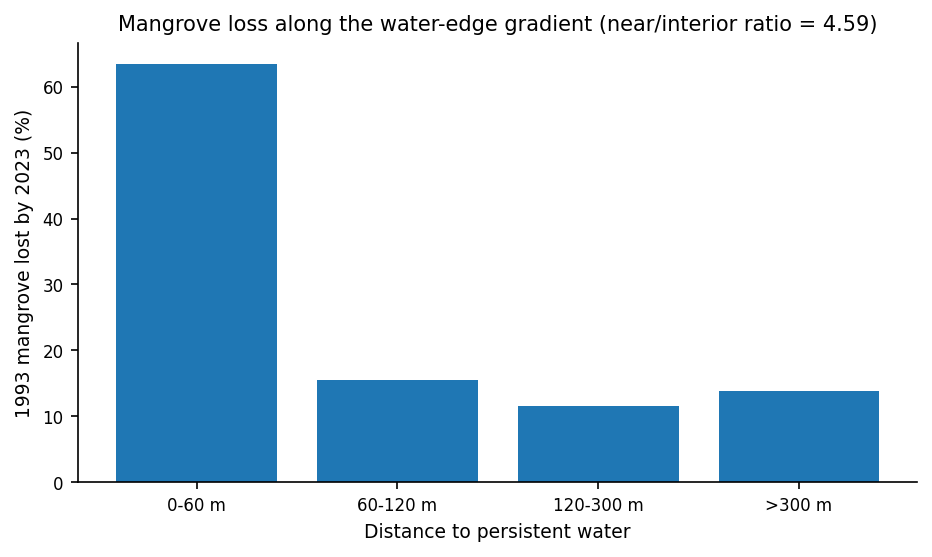

In [ ]:
# 27. Water-edge exposure gradient
order = ['0-60 m','60-120 m','120-300 m','>300 m']
water2 = water.copy()
water2['distance_bin'] = pd.Categorical(water2['distance_bin'],categories=order,ordered=True)
water2 = water2.sort_values('distance_bin').reset_index(drop=True)
near = float(water2.loc[water2['distance_bin'].astype(str).eq('0-60 m'),'loss_fraction'].iloc[0])
interior = float(water2.loc[water2['distance_bin'].astype(str).eq('>300 m'),'loss_fraction'].iloc[0])
risk_ratio = near/interior if interior > 0 else np.nan
water2['loss_pct'] = 100*water2['loss_fraction']
water2.to_csv(TAB/'17_water_edge_exposure.csv',index=False)
pd.DataFrame([{'near_vs_interior_loss_ratio':risk_ratio}]).to_csv(TAB/'18_water_edge_descriptive_ratio.csv',index=False)

fig, ax = plt.subplots(figsize=(6.1,3.6))
ax.bar(water2['distance_bin'].astype(str),water2['loss_pct'])
ax.set_xlabel('Distance to persistent water')

ax.set_ylabel('1993 mangrove lost by 2023 (%)')
ax.set_title(f'Mangrove loss along the water-edge gradient (near/interior ratio = {risk_ratio:.2f})')
save_figure('Fig14_water_edge_loss_gradient')
plt.show()


,year,stable_mangrove_area_ha,median_decline_magnitude,p90_decline_magnitude
0,1994,832.487060,0.328007,0.630354
1,1995,1063.667965,0.325798,0.571480
2,1996,907.539731,0.395024,0.631161
3,1997,1405.764609,0.289703,0.630350
4,1998,1296.767874,0.130626,0.535493


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Figures/Fig15_peak_NDMI_decline_timing.png


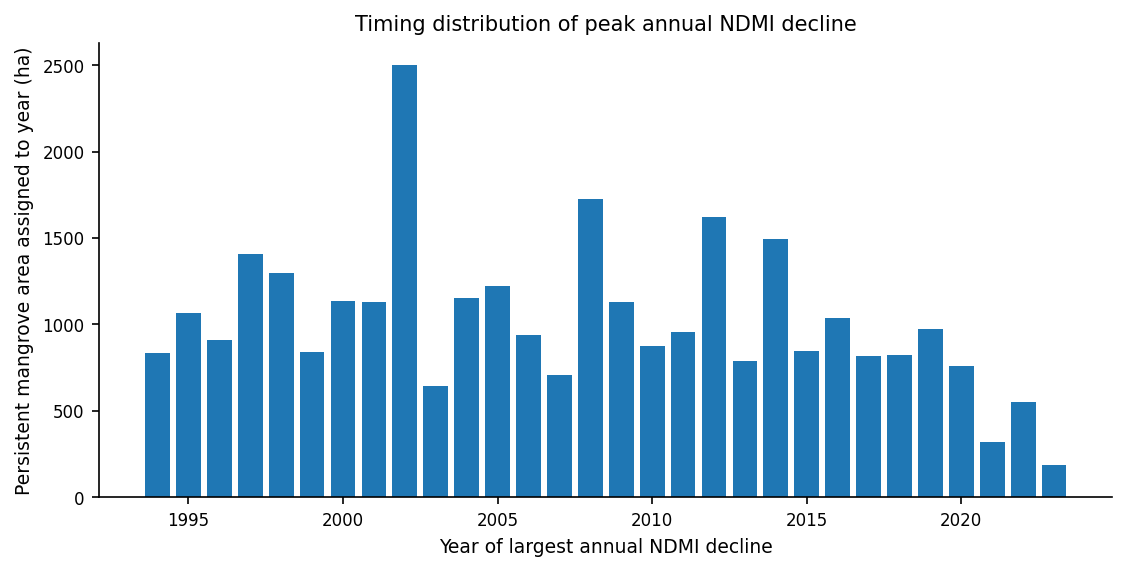

In [ ]:
# 28. Peak annual NDMI-decline timing over persistent mangrove only
with rasterio.open(ROOT/'MMFR_RF_class_probability_1993.tif') as src:
    hard93 = src.read(1) >= 0.5
    row_area = geodesic_row_pixel_area_ha(src)
with rasterio.open(ROOT/'MMFR_RF_class_probability_2023.tif') as src:
    hard23 = src.read(1) >= 0.5
with rasterio.open(ROOT/'MMFR_largest_annual_NDMI_decline.tif') as src:
    decline_year = src.read(1)
    decline_mag = src.read(2)

stable = hard93 & hard23 & np.isfinite(decline_year) & np.isfinite(decline_mag)
rows = []
for y in range(1994,2024):
    m = stable & (np.rint(decline_year).astype(int) == y)
    if m.any():
        rows.append({
            'year':y,
            'stable_mangrove_area_ha':raster_mask_area_ha(m,row_area),
            'median_decline_magnitude':float(np.nanmedian(decline_mag[m])),
            'p90_decline_magnitude':float(np.nanpercentile(decline_mag[m],90))
        })
decline_timing = pd.DataFrame(rows)
decline_timing.to_csv(TAB/'19_peak_NDMI_decline_timing.csv',index=False)
display(decline_timing.head())

fig, ax = plt.subplots(figsize=(7.4,3.7))
ax.bar(decline_timing['year'],decline_timing['stable_mangrove_area_ha'])
ax.set_xlabel('Year of largest annual NDMI decline')
ax.set_ylabel('Persistent mangrove area assigned to year (ha)')
ax.set_title('Timing distribution of peak annual NDMI decline')
save_figure('Fig15_peak_NDMI_decline_timing')
plt.show()


# F. Publication maps generated directly in Colab

All map figures are reprojected to **UTM Zone 47N (EPSG:32647)** for metric axes. No desktop GIS is required. Each map is saved as its own 600 dpi figure so the manuscript layout can combine panels later without re-running GIS software.


In [ ]:
# ============================================================
# PUBLICATION MAP HELPERS — LOCAL LANDSAT BASEMAP VERSION
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import Normalize

import rasterio
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)

DST_CRS = 'EPSG:32647'

RAW_GEE = Path(
    '/content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/RAW_GEE'
)

LANDSAT_BASEMAP = {
    1993: RAW_GEE / 'Landsat_1993.tif',
    2003: RAW_GEE / 'Landsat_2003.tif',
    2013: RAW_GEE / 'Landsat_2013.tif',
    2023: RAW_GEE / 'Landsat_2023.tif',
}


# ============================================================
# MAP COLORS
# ============================================================

# Classification maps:
# non-mangrove intentionally transparent so the Landsat
# image itself remains visible.
CLASS_BINARY_SPEC = {
    0: {
        'label': 'Non-mangrove',
        'rgba': (0.45, 0.05, 0.05, 0.00)
    },
    1: {
        'label': 'Mangrove',
        'rgba': (0.22, 1.00, 0.08, 0.82)
    }
}


# Change map:
CHANGE_CLASS_SPEC = {
    0: {
        'label': 'Persistent non-mangrove',
        'rgba': (0.42, 0.02, 0.05, 0.20)
    },
    1: {
        'label': 'Loss',
        'rgba': (1.00, 0.48, 0.60, 0.92)
    },
    2: {
        'label': 'Gain',
        'rgba': (0.62, 0.95, 0.38, 0.92)
    },
    3: {
        'label': 'Persistent mangrove',
        'rgba': (0.00, 0.28, 0.08, 0.90)
    }
}


# ============================================================
# BASIC RASTER REPROJECTION
# ============================================================

def reproject_band(
    path,
    band=1,
    resampling=Resampling.nearest,
    dst_res=30
):
    with rasterio.open(path) as src:

        transform, width, height = calculate_default_transform(
            src.crs,
            DST_CRS,
            src.width,
            src.height,
            *src.bounds,
            resolution=dst_res
        )

        out = np.full(
            (height, width),
            np.nan,
            dtype='float32'
        )

        reproject(
            source=rasterio.band(src, band),
            destination=out,

            src_transform=src.transform,
            src_crs=src.crs,

            dst_transform=transform,
            dst_crs=DST_CRS,

            resampling=resampling,
            dst_nodata=np.nan
        )

    extent = [
        transform.c,
        transform.c + transform.a * width,
        transform.f + transform.e * height,
        transform.f
    ]

    return out, extent


# ============================================================
# LANDSAT RGB DETECTION
# ============================================================

def _find_rgb_band_indexes(src, year):
    """
    Automatically determine RGB bands.

    Priority:
    1. Band descriptions such as blue/green/red
    2. If exactly 3 bands, use 1/2/3 as already-prepared RGB
    3. Sensor-specific fallback for raw Landsat bands
    """

    descriptions = [
        (d or '').lower()
        for d in src.descriptions
    ]

    # --------------------------------------------------------
    # Best case: exported band names exist
    # --------------------------------------------------------

    def find_name(names):
        for i, desc in enumerate(descriptions):
            for name in names:
                if desc == name or name in desc:
                    return i + 1
        return None

    red = find_name([
        'red'
    ])

    green = find_name([
        'green'
    ])

    blue = find_name([
        'blue'
    ])

    if (
        red is not None and
        green is not None and
        blue is not None
    ):
        return [red, green, blue]


    # --------------------------------------------------------
    # Already prepared RGB image
    # --------------------------------------------------------

    if src.count == 3:
        return [1, 2, 3]


    # --------------------------------------------------------
    # Raw Landsat fallback
    # --------------------------------------------------------

    if year in [1993, 2003]:
        # Landsat 5 TM / Landsat 7 ETM+
        return [3, 2, 1]

    else:
        # Landsat 8 OLI
        return [4, 3, 2]


# ============================================================
# CONTRAST STRETCH
# ============================================================

def _stretch_channel(
    arr,
    p_low=2,
    p_high=98,
    gamma=0.95
):
    arr = arr.astype('float32')

    valid = np.isfinite(arr)

    if valid.sum() == 0:
        return np.zeros_like(arr)

    values = arr[valid]

    lo = np.nanpercentile(
        values,
        p_low
    )

    hi = np.nanpercentile(
        values,
        p_high
    )

    if hi <= lo:
        hi = lo + 1e-6

    out = (
        (arr - lo) /
        (hi - lo)
    )

    out = np.clip(
        out,
        0,
        1
    )

    out = np.power(
        out,
        gamma
    )

    out[~valid] = 0

    return out


# ============================================================
# LOAD / REPROJECT LANDSAT RGB
# ============================================================

def load_landsat_rgb(
    year,
    dst_res=60
):
    """
    Landsat is only used as a visual basemap.
    60 m visualization resolution saves memory while the
    classification overlay remains at 30 m.
    """

    path = LANDSAT_BASEMAP[year]

    if not path.exists():
        raise FileNotFoundError(
            f'Landsat basemap not found: {path}'
        )

    with rasterio.open(path) as src:

        rgb_bands = _find_rgb_band_indexes(
            src,
            year
        )

        print(
            f'{year} Landsat RGB bands:',
            rgb_bands,
            '| descriptions:',
            src.descriptions
        )

        transform, width, height = (
            calculate_default_transform(
                src.crs,
                DST_CRS,
                src.width,
                src.height,
                *src.bounds,
                resolution=dst_res
            )
        )

        rgb = np.full(
            (3, height, width),
            np.nan,
            dtype='float32'
        )

        for j, band_id in enumerate(rgb_bands):

            reproject(
                source=rasterio.band(
                    src,
                    band_id
                ),

                destination=rgb[j],

                src_transform=src.transform,
                src_crs=src.crs,

                dst_transform=transform,
                dst_crs=DST_CRS,

                resampling=Resampling.bilinear,

                dst_nodata=np.nan
            )


    # --------------------------------------------------------
    # Independent contrast stretch per RGB band
    # --------------------------------------------------------

    rgb_display = np.stack(
        [
            _stretch_channel(
                rgb[i],
                p_low=2,
                p_high=98,
                gamma=0.92
            )
            for i in range(3)
        ],
        axis=-1
    )


    extent = [
        transform.c,
        transform.c + transform.a * width,
        transform.f + transform.e * height,
        transform.f
    ]

    return rgb_display, extent


# ============================================================
# CLASS ARRAY -> RGBA
# ============================================================

def rgba_from_classes(
    arr,
    spec
):
    rgba = np.zeros(
        arr.shape + (4,),
        dtype='float32'
    )

    for code_id, cfg in spec.items():

        mask = (
            np.isfinite(arr)
            &
            (
                np.rint(arr)
                .astype('int32')
                == int(code_id)
            )
        )

        rgba[mask] = np.array(
            cfg['rgba'],
            dtype='float32'
        )

    return rgba


# ============================================================
# CARTOGRAPHIC ELEMENTS
# ============================================================

def add_north_arrow(ax):

    ax.annotate(
        'N',

        xy=(0.94, 0.94),
        xytext=(0.94, 0.83),

        xycoords='axes fraction',

        ha='center',
        va='center',

        fontsize=8,
        fontweight='bold',

        arrowprops=dict(
            arrowstyle='-|>',
            lw=1.2,
            color='black'
        ),

        bbox=dict(
            facecolor='white',
            alpha=0.72,
            edgecolor='none',
            pad=1
        ),

        zorder=10
    )


def add_scale_bar(
    ax,
    length_km=10
):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    length_m = (
        length_km * 1000
    )

    x0 = (
        xmin +
        0.06 *
        (xmax - xmin)
    )

    y0 = (
        ymin +
        0.05 *
        (ymax - ymin)
    )


    # white halo
    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],

        color='white',
        linewidth=4,

        solid_capstyle='butt',

        zorder=8
    )


    # black bar
    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],

        color='black',
        linewidth=2,

        solid_capstyle='butt',

        zorder=9
    )


    ax.text(
        x0 + length_m / 2,
        y0 + 650,

        f'{length_km} km',

        ha='center',
        va='bottom',

        fontsize=7,

        bbox=dict(
            facecolor='white',
            alpha=0.72,
            edgecolor='none',
            pad=1
        ),

        zorder=10
    )


# ============================================================
# FOUR-EPOCH CLASSIFICATION PANEL
# ============================================================

def save_classification_panel(
    years=EPOCHS,
    name='Map_RF_mangrove_epochs_panel'
):

    fig, axes = plt.subplots(
        2,
        2,

        figsize=(8.0, 10.8),

        constrained_layout=False
    )

    axes = axes.ravel()

    panel_letters = [
        'a',
        'b',
        'c',
        'd'
    ]


    for (
        ax,
        year,
        letter
    ) in zip(
        axes,
        years,
        panel_letters
    ):

        # ====================================================
        # LANDSAT OF THE SAME YEAR
        # ====================================================

        rgb, rgb_extent = (
            load_landsat_rgb(
                year,
                dst_res=60
            )
        )

        ax.imshow(
            rgb,

            extent=rgb_extent,

            origin='upper',

            interpolation='bilinear',

            zorder=1
        )


        # ====================================================
        # RF CLASSIFICATION
        # ====================================================

        rf_path = (
            ROOT /
            f'MMFR_RF_class_probability_{year}.tif'
        )

        cls, cls_extent = (
            reproject_band(
                rf_path,

                band=1,

                resampling=Resampling.nearest,

                dst_res=30
            )
        )

        rgba = rgba_from_classes(
            cls,
            CLASS_BINARY_SPEC
        )

        ax.imshow(
            rgba,

            extent=cls_extent,

            origin='upper',

            interpolation='nearest',

            zorder=3
        )


        # ====================================================
        # EXACT MAP EXTENT
        # ====================================================

        xmin, xmax, ymin, ymax = (
            cls_extent
        )

        ax.set_xlim(
            xmin,
            xmax
        )

        ax.set_ylim(
            ymin,
            ymax
        )

        ax.set_aspect(
            'equal'
        )

        ax.set_xticks([])
        ax.set_yticks([])

        ax.grid(False)


        # ====================================================
        # PANEL YEAR
        # ====================================================

        ax.text(
            0.02,
            0.985,

            f'({letter}) {year}',

            transform=ax.transAxes,

            ha='left',
            va='top',

            fontsize=10,
            fontweight='bold',

            bbox=dict(
                facecolor='white',
                alpha=0.82,
                edgecolor='none',
                pad=2
            ),

            zorder=10
        )


        # ====================================================
        # MAPPED AREA
        # ====================================================

        with rasterio.open(
            rf_path
        ) as src:

            hard = (
                src.read(1)
                .astype(float)
            )

            row_area = (
                geodesic_row_pixel_area_ha(
                    src
                )
            )

        area_ha = raster_mask_area_ha(
            hard >= 0.5,
            row_area
        )


        ax.text(
            0.02,
            0.91,

            f'{area_ha:,.0f} ha',

            transform=ax.transAxes,

            ha='left',
            va='top',

            fontsize=7.5,

            bbox=dict(
                facecolor='white',
                alpha=0.78,
                edgecolor='0.65',
                linewidth=0.4,
                boxstyle='round,pad=0.22'
            ),

            zorder=10
        )


        add_north_arrow(ax)
        add_scale_bar(
            ax,
            length_km=10
        )


    # ========================================================
    # SHARED LEGEND
    # ========================================================

    handles = [
        Patch(
            facecolor=
            CLASS_BINARY_SPEC[1]['rgba'],

            edgecolor='none',

            label='Mangrove'
        )
    ]


    fig.legend(
        handles=handles,

        loc='lower center',

        bbox_to_anchor=(
            0.5,
            0.018
        ),

        ncol=1,

        frameon=False,

        fontsize=9
    )


    # NO internal super-title.
    # The journal caption will provide the figure title.
    # This prevents overlap with panel (a)/(b).


    fig.subplots_adjust(
        left=0.02,
        right=0.98,

        bottom=0.055,
        top=0.995,

        wspace=0.035,
        hspace=0.035
    )


    MAPS.mkdir(
        parents=True,
        exist_ok=True
    )


    png_path = (
        MAPS /
        f'{name}.png'
    )

    pdf_path = (
        MAPS /
        f'{name}.pdf'
    )


    fig.savefig(
        png_path,

        dpi=450,

        facecolor='white'
    )


    fig.savefig(
        pdf_path,

        dpi=300,

        facecolor='white'
    )


    print(
        'Saved:',
        png_path
    )

    print(
        'Saved:',
        pdf_path
    )


    plt.show()

    plt.close(fig)


# ============================================================
# 2023 RF PROBABILITY MAP
# ============================================================

def save_probability_map(
    path,
    band,
    title,
    name,
    basemap_year=2023
):

    # Landsat background
    rgb, rgb_extent = (
        load_landsat_rgb(
            basemap_year,
            dst_res=60
        )
    )


    # probability raster
    arr, extent = (
        reproject_band(
            path,

            band=band,

            resampling=Resampling.bilinear,

            dst_res=30
        )
    )


    fig, ax = plt.subplots(
        figsize=(5.5, 7.3)
    )


    ax.imshow(
        rgb,

        extent=rgb_extent,

        origin='upper',

        interpolation='bilinear',

        zorder=1
    )


    prob = np.clip(
        arr,
        0,
        1
    )


    # Low probabilities nearly transparent;
    # higher probabilities increasingly visible.
    alpha_prob = (
        0.12 +
        0.72 * prob
    )

    alpha_prob[
        ~np.isfinite(prob)
    ] = 0


    im = ax.imshow(
        prob,

        extent=extent,

        origin='upper',

        cmap='YlGn',

        vmin=0,
        vmax=1,

        alpha=alpha_prob,

        interpolation='nearest',

        zorder=3
    )


    xmin, xmax, ymin, ymax = (
        extent
    )

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.set_ylim(
        ymin,
        ymax
    )

    ax.set_aspect(
        'equal'
    )


    ax.set_xlabel(
        'Easting (m, UTM 47N)'
    )

    ax.set_ylabel(
        'Northing (m, UTM 47N)'
    )

    ax.set_title(
        title
    )


    cb = fig.colorbar(
        im,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    cb.set_label(
        'Mangrove probability'
    )


    add_north_arrow(ax)
    add_scale_bar(
        ax,
        10
    )


    MAPS.mkdir(
        parents=True,
        exist_ok=True
    )


    fig.savefig(
        MAPS / f'{name}.png',

        dpi=450,

        facecolor='white'
    )


    fig.savefig(
        MAPS / f'{name}.pdf',

        dpi=300,

        facecolor='white'
    )


    plt.show()

    plt.close(fig)


# ============================================================
# CHANGE MAP
# ============================================================

def save_change_map(
    path,
    band,
    title,
    name,
    basemap_year=2023
):

    rgb, rgb_extent = (
        load_landsat_rgb(
            basemap_year,
            dst_res=60
        )
    )


    arr, extent = (
        reproject_band(
            path,

            band=band,

            resampling=Resampling.nearest,

            dst_res=30
        )
    )


    rgba = rgba_from_classes(
        arr,
        CHANGE_CLASS_SPEC
    )


    fig, ax = plt.subplots(
        figsize=(5.7, 7.4)
    )


    ax.imshow(
        rgb,

        extent=rgb_extent,

        origin='upper',

        interpolation='bilinear',

        zorder=1
    )


    ax.imshow(
        rgba,

        extent=extent,

        origin='upper',

        interpolation='nearest',

        zorder=3
    )


    xmin, xmax, ymin, ymax = (
        extent
    )

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.set_ylim(
        ymin,
        ymax
    )


    ax.set_aspect(
        'equal'
    )


    ax.set_xlabel(
        'Easting (m, UTM 47N)'
    )

    ax.set_ylabel(
        'Northing (m, UTM 47N)'
    )

    ax.set_title(
        title
    )


    handles = [
        Patch(
            facecolor=cfg['rgba'],
            edgecolor='none',
            label=cfg['label']
        )
        for cfg
        in CHANGE_CLASS_SPEC.values()
    ]


    ax.legend(
        handles=handles,

        loc='lower right',

        frameon=True,

        title='Transition class',

        fontsize=7.5
    )


    add_north_arrow(ax)
    add_scale_bar(
        ax,
        10
    )


    MAPS.mkdir(
        parents=True,
        exist_ok=True
    )


    fig.savefig(
        MAPS / f'{name}.png',

        dpi=450,

        facecolor='white'
    )


    fig.savefig(
        MAPS / f'{name}.pdf',

        dpi=300,

        facecolor='white'
    )


    plt.show()

    plt.close(fig)


# ============================================================
# NDMI DECLINE-YEAR MAP + LANDSAT
# ============================================================

def save_ndmi_decline_map(
    name='Map_peak_NDMI_decline_year',
    basemap_year=2023
):

    # --------------------------------------------------------
    # Landsat background
    # --------------------------------------------------------

    rgb, rgb_extent = (
        load_landsat_rgb(
            basemap_year,
            dst_res=60
        )
    )


    # --------------------------------------------------------
    # Decline year
    # --------------------------------------------------------

    decline_year, extent = (
        reproject_band(
            ROOT /
            'MMFR_largest_annual_NDMI_decline.tif',

            band=1,

            resampling=Resampling.nearest,

            dst_res=30
        )
    )


    # --------------------------------------------------------
    # Explicit persistent mangrove mask:
    # mangrove in BOTH 1993 and 2023
    # --------------------------------------------------------

    cls93, _ = reproject_band(
        ROOT /
        'MMFR_RF_class_probability_1993.tif',

        band=1,

        resampling=Resampling.nearest,

        dst_res=30
    )


    cls23, _ = reproject_band(
        ROOT /
        'MMFR_RF_class_probability_2023.tif',

        band=1,

        resampling=Resampling.nearest,

        dst_res=30
    )


    persistent = (
        (cls93 >= 0.5)
        &
        (cls23 >= 0.5)
        &
        np.isfinite(decline_year)
    )


    decline_masked = np.where(
        persistent,
        decline_year,
        np.nan
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(5.7, 7.4)
    )


    ax.imshow(
        rgb,

        extent=rgb_extent,

        origin='upper',

        interpolation='bilinear',

        zorder=1
    )


    masked = np.ma.masked_invalid(
        decline_masked
    )


    im = ax.imshow(
        masked,

        extent=extent,

        origin='upper',

        interpolation='nearest',

        cmap='viridis',

        vmin=1994,
        vmax=2023,

        alpha=0.82,

        zorder=3
    )


    xmin, xmax, ymin, ymax = (
        extent
    )

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.set_ylim(
        ymin,
        ymax
    )

    ax.set_aspect(
        'equal'
    )


    ax.set_xlabel(
        'Easting (m, UTM 47N)'
    )

    ax.set_ylabel(
        'Northing (m, UTM 47N)'
    )


    ax.set_title(
        'Year of largest annual NDMI decline'
    )


    cb = fig.colorbar(
        im,

        ax=ax,

        fraction=0.035,
        pad=0.02,

        ticks=[
            1995,
            2000,
            2005,
            2010,
            2015,
            2020,
            2023
        ]
    )


    cb.set_label(
        'Year'
    )


    add_north_arrow(ax)
    add_scale_bar(
        ax,
        10
    )


    MAPS.mkdir(
        parents=True,
        exist_ok=True
    )


    fig.savefig(
        MAPS / f'{name}.png',

        dpi=450,

        facecolor='white'
    )


    fig.savefig(
        MAPS / f'{name}.pdf',

        dpi=300,

        facecolor='white'
    )


    plt.show()

    plt.close(fig)


print(
    'LOCAL LANDSAT publication map helpers ready.'
)

LOCAL LANDSAT publication map helpers ready.


In [ ]:
# 32. Four epoch classification maps — single 2×2 publication figure
save_classification_panel(
    years=EPOCHS,
    name='Map_RF_mangrove_epochs_panel'
)


Output hidden; open in https://colab.research.google.com to view.

2023 Landsat RGB bands: [4, 3, 2] | descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11')


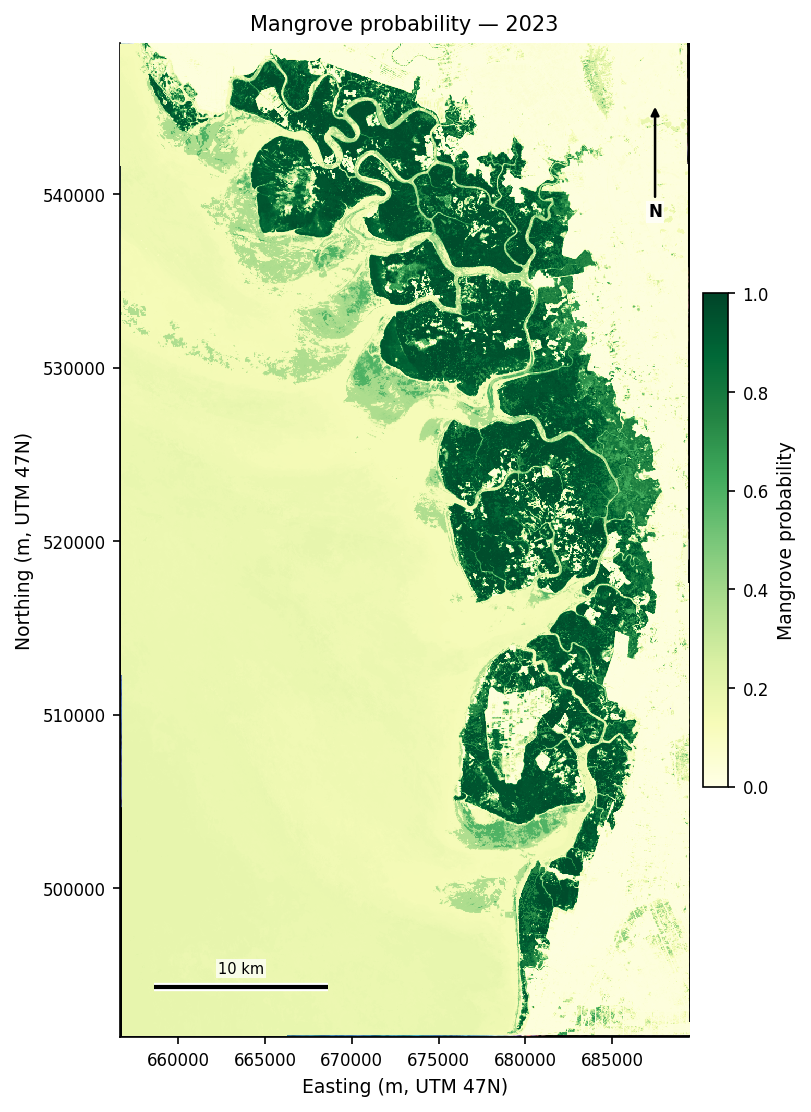

In [ ]:
# 33. 2023 continuous mangrove probability
# Landsat 2023 is used as contextual basemap.

save_probability_map(
    ROOT / 'MMFR_RF_class_probability_2023.tif',
    band=2,
    title='Mangrove probability — 2023',
    name='Map_RF_probability_2023',
    basemap_year=2023
)

TypeError: add_world_imagery() missing 1 required positional argument: 'extent'

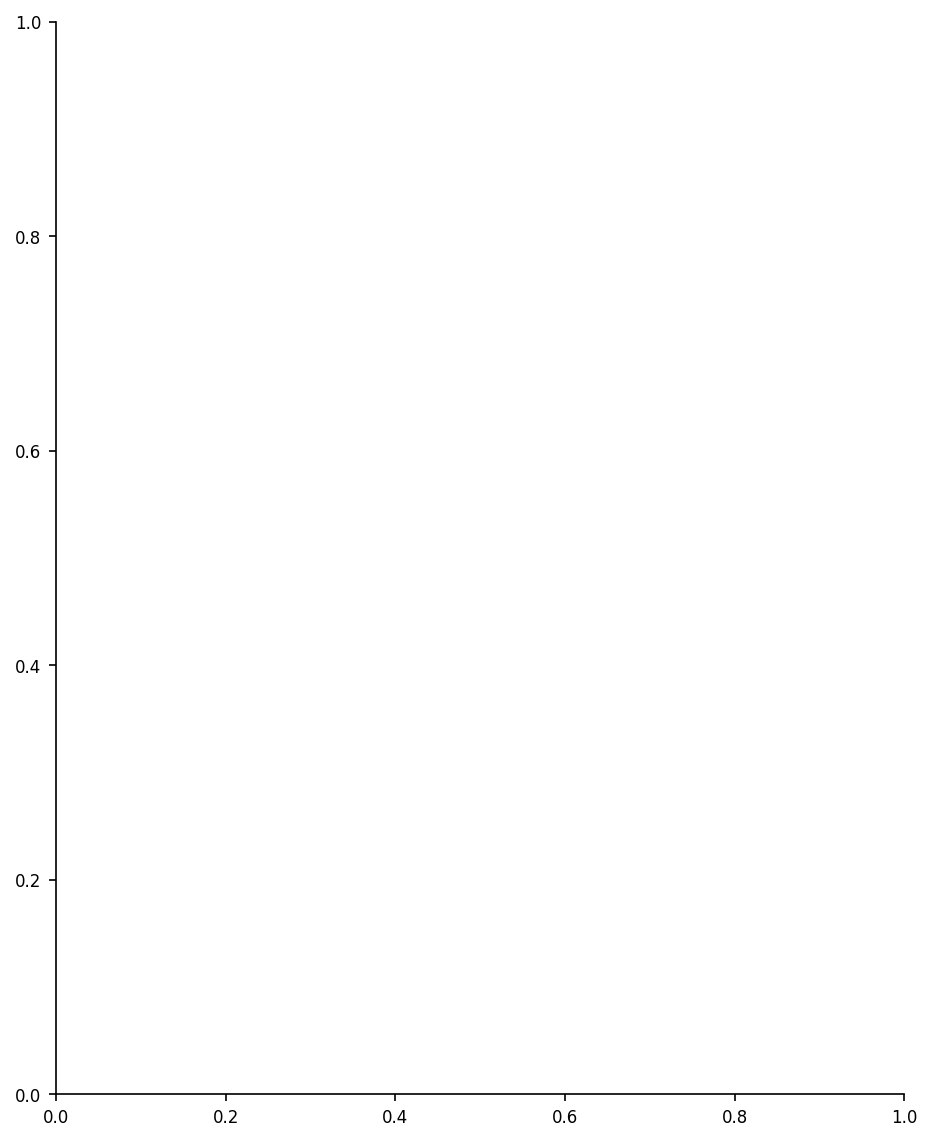

In [ ]:
# 34. 1993–2023 categorical transition map with requested color logic
save_change_map(
    ROOT/'MMFR_change_1993_2023.tif',
    band=1,
    title='Mangrove transition classes in MMFR, 1993–2023',
    name='Map_change_1993_2023'
)


Saved: /content/drive/MyDrive/MMFR_Q3_REVISION/IPYNB/Data/ULTIMATE_SCOPUS/Maps/Map_peak_NDMI_decline_year.png


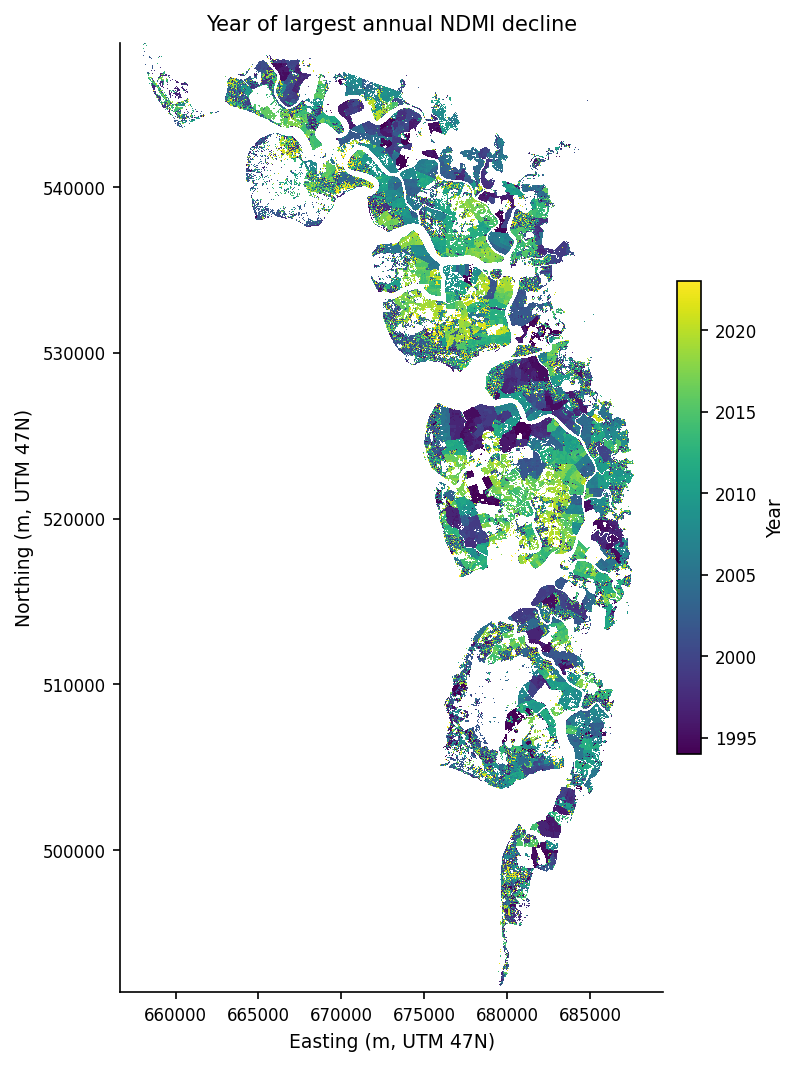

In [ ]:
# 33. Peak annual NDMI decline year map, masked to persistent mangrove
arr, extent = reproject_band(
    ROOT/'MMFR_largest_annual_NDMI_decline.tif',band=1,
    resampling=Resampling.nearest,dst_res=30
)
fig, ax = plt.subplots(figsize=(5.4,7.0))
im = ax.imshow(arr,extent=extent,origin='upper',interpolation='nearest')
ax.set_xlabel('Easting (m, UTM 47N)')
ax.set_ylabel('Northing (m, UTM 47N)')
ax.set_title('Year of largest annual NDMI decline')
ax.set_aspect('equal')
cb = fig.colorbar(im,ax=ax,fraction=0.035,pad=0.02)
cb.set_label('Year')
save_figure('Map_peak_NDMI_decline_year',folder=MAPS)
plt.show()


# G. Compile final tables, machine-readable summary, and reproducibility manifest


In [ ]:
# 34. Compile an Excel workbook of all manuscript/supplement tables
workbook = TAB/'MMFR_ULTIMATE_analysis_tables.xlsx'
with pd.ExcelWriter(workbook,engine='openpyxl') as w:
    readiness.to_excel(w,sheet_name='readiness',index=False)
    epoch.to_excel(w,sheet_name='epoch_summary',index=False)
    val.to_excel(w,sheet_name='validation',index=False)
    cm_table.to_excel(w,sheet_name='internal_confusion',index=False)
    external_repeat_summary.to_excel(w,sheet_name='CGMD_repeat_summary',index=False)
    external_points.to_excel(w,sheet_name='CGMD_point_metrics',index=False)
    external_cm.to_excel(w,sheet_name='CGMD_confusion',index=False)
    acc_rep.to_excel(w,sheet_name='CGMD_all_repeats',index=False)
    spatial_cv.to_excel(w,sheet_name='spatial_sensitivity',index=False)
    imp.to_excel(w,sheet_name='RF_importance',index=False)
    rf_cgmd.to_excel(w,sheet_name='RF_vs_CGMD',index=False)
    threshold_df.to_excel(w,sheet_name='threshold_sensitivity',index=False)
    prob_summary.to_excel(w,sheet_name='probability_summary',index=False)
    change_area.to_excel(w,sheet_name='change_composition',index=False)
    trend_table.to_excel(w,sheet_name='trend_tests',index=False)
    cross_sensor.to_excel(w,sheet_name='cross_sensor',index=False)
    climate_flags.to_excel(w,sheet_name='climate_flags',index=False)
    lag.to_excel(w,sheet_name='lag_associations',index=False)
    coef.to_excel(w,sheet_name='HAC_models',index=False)
    vif.to_excel(w,sheet_name='VIF',index=False)
    water2.to_excel(w,sheet_name='water_exposure',index=False)
    decline_timing.to_excel(w,sheet_name='NDMI_decline_timing',index=False)
    annual.to_excel(w,sheet_name='annual_merged',index=False)
print('Saved:',workbook)


In [ ]:
# 35. Auto-generate concise scientific result summary
rf_start = float(epoch.loc[epoch['year'].eq(1993),'raw_mapped_area_ha'].iloc[0])
rf_end = float(epoch.loc[epoch['year'].eq(2023),'raw_mapped_area_ha'].iloc[0])
rf_change_pct = 100*(rf_end-rf_start)/rf_start
cg_start = float(cgmd.loc[cgmd['year'].eq(1993),'CGMD_extent_area_ha'].iloc[0])
cg_end = float(cgmd.loc[cgmd['year'].eq(2023),'CGMD_extent_area_ha'].iloc[0])
cg_change_pct = 100*(cg_end-cg_start)/cg_start

ndmi_row = trend_table[trend_table['variable'].eq('NDMI_median')].iloc[0]
strong_lag = lag.dropna(subset=['p_FDR']).sort_values('p_FDR').head(5)

summary_lines = [
    '# MMFR Ultimate Analysis — Automatically Generated Result Summary',
    '',
    f'Generated: {datetime.now().isoformat(timespec="seconds")}',
    '',
    '## Mapping performance',
    '### Internal model diagnostic',
    *[f'- {int(r.year)}: internal hold-out OA={r.OA:.3f}, Kappa={r.Kappa:.3f}, mangrove F1={r.F1_mangrove:.3f}.' for _,r in val.iterrows()],
    '',
    '### Exact-year CGMD external spatial audit',
    *[f'- {int(r.year)}: repeated balanced agreement={r.balanced_agreement_mean:.3f} '
      f'(repeat range {r.balanced_agreement_min:.3f}–{r.balanced_agreement_max:.3f}), '
      f'Kappa={r.Kappa_mean:.3f}, mangrove PA={r.PA_mangrove_mean:.3f}, '
      f'mangrove UA={r.UA_mangrove_mean:.3f}.' for _,r in external_repeat_summary.iterrows()],
    '',
    'The CGMD audit is an external-product agreement test using balanced class sampling; it is not field ground truth or area-weighted accuracy.',
    '',
    '## Long-term extent',
    f'- Study-specific RF mapped area changed from {rf_start:,.1f} ha (1993) to {rf_end:,.1f} ha (2023), equivalent to {rf_change_pct:+.2f}%.',
    f'- CGMD annual context changed from {cg_start:,.1f} ha (1993) to {cg_end:,.1f} ha (2023), equivalent to {cg_change_pct:+.2f}%.',
    '- The RF–CGMD trajectory difference should be discussed as product/method disagreement, not resolved by assuming one is ground truth.',
    '',
    '## Annual canopy condition',
    f'- NDMI Theil–Sen slope: {ndmi_row.TheilSen_slope_per_year:+.6f} per year; Hamed–Rao p={ndmi_row.HamedRao_p:.4g}.',
    f'- Pettitt candidate change year: {ndmi_row.Pettitt_year} (p={ndmi_row.Pettitt_p:.4g}).',
    '',
    '## Water-edge exposure',
    f'- Loss fraction within 0–60 m of persistent water was {near*100:.1f}%, compared with {interior*100:.1f}% at >300 m; descriptive near/interior ratio={risk_ratio:.2f}.',
    '- This is spatial exposure evidence and does not by itself establish sea-level-rise causation.',
    '',
    '## Climate/ocean QC',
    f'- Robust primary-driver outlier years flagged: {sorted(flagged_primary_years)}.',
    '',
    '## Strongest detrended lag associations after FDR correction',
]
for _,r in strong_lag.iterrows():
    summary_lines.append(
        f'- {r.response} vs {r.driver}, lag {int(r.lag_years)} yr: ρ={r.spearman_rho:+.3f}, FDR p={r.p_FDR:.4g}.'
    )
summary_lines += [
    '',
    '## Interpretation constraint',
    'Use association language for climate/ocean and water-edge results. Do not convert these results into causal attribution without an additional causal design.'
]

summary_path = REP/'MMFR_ULTIMATE_results_summary.md'
summary_path.write_text('\n'.join(summary_lines),encoding='utf-8')
print(summary_path.read_text(encoding='utf-8'))


In [ ]:
# 36. Reproducibility manifest
packages = ['numpy','pandas','matplotlib','scipy','pymannkendall','scikit-learn','statsmodels','rasterio','pyproj','openpyxl']
versions = {}
for p in packages:
    try:
        versions[p] = mdlib.version(p)
    except Exception:
        versions[p] = None

manifest = {
    'generated': datetime.now().isoformat(timespec='seconds'),
    'python': platform.python_version(),
    'platform': platform.platform(),
    'input_root': str(ROOT),
    'output_root': str(FINAL),
    'packages': versions,
    'method_notes': {
        'internal_validation':'hold-out model diagnostic',
        'external_validation':'CGMD exact-year balanced spatial audit; 10 repeats; external product agreement, not field ground truth',
        'spatial_block':'secondary separability sensitivity only',
        'CGMD':'annual benchmark/context plus exact-year external agreement reference; not field ground truth',
        'climate_inference':'association; detrended; lagged Spearman + FDR; HAC OLS sensitivity',
        'area_adjustment':'no Olofsson accuracy-adjusted area unless probability reference sampling is available'
    }
}
(REP/'reproducibility_manifest.json').write_text(json.dumps(manifest,indent=2),encoding='utf-8')
display(pd.DataFrame({'package':versions.keys(),'version':versions.values()}))


In [ ]:
# 37. Final output inventory
outputs = []
for folder in [FIG, MAPS, TAB, REP]:
    for p in sorted(folder.glob('*')):
        if p.is_file():
            outputs.append({
                'category':folder.name,
                'file':p.name,
                'size_MB':p.stat().st_size/(1024**2)
            })
output_inventory = pd.DataFrame(outputs)
output_inventory.to_csv(FINAL/'MMFR_ULTIMATE_output_inventory.csv',index=False)
display(output_inventory)
print('\nULTIMATE ANALYSIS COMPLETE')
print('All outputs:', FINAL)


---

## Manuscript-use guidance — revised

### Main-paper candidates

- **Fig01** exact-year CGMD repeated external agreement, with internal hold-out shown only as contextual model diagnostics.
- **Fig03** RF snapshots vs CGMD annual extent context.
- **Fig07** annual NDMI trajectory with robust trend/change-point screening.
- **Fig12** detrended lag-association heatmap.
- **Fig13** HAC coefficient plot.
- **Fig14** water-edge loss gradient.
- **Fig15** timing of peak annual NDMI decline.
- **Map_RF_mangrove_epochs_panel** — one 2×2 satellite-basemap figure for 1993, 2003, 2013, and 2023.
- **Map_change_1993_2023** — categorical transition map with four discrete classes and a categorical legend.

### Supplementary candidates

- internal hold-out validation details;
- CGMD point-level confusion matrices;
- spatial-block separability sensitivity;
- probability-threshold sensitivity;
- probability distributions by epoch;
- RF predictor importance;
- Landsat–MODIS EVI sensitivity;
- CGMD FCC trajectory;
- climate anomaly heatmap;
- full model/VIF tables.

### Recommended validation wording

Use:

> Classification separability was first evaluated through an internal hold-out test. To obtain a more spatially independent assessment, the final RF maps were additionally compared against the exact-year CGMD product using repeated balanced stratified sampling after excluding the vicinity of original manual samples and uncertain reference boundaries. Because CGMD is itself a remote-sensing product and the audit uses equal class allocation, the resulting values are interpreted as balanced external product agreement rather than field-ground-truth or area-weighted map accuracy.

### Claims to avoid

- Do not call CGMD ground truth.
- Do not present the internal 1993 OA=1.0 as proof of perfect map accuracy.
- Do not force validation results into a preselected numerical range.
- Do not call the balanced CGMD score an area-weighted overall accuracy.
- Do not state that sea-level rise caused the mapped water-edge loss.
- Do not infer climate response from only the four mapped area epochs.
